In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import jvp, vjp, functional_call

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
torch.manual_seed(0)

In [2]:
class MLP(nn.Module):
    def __init__(self, d_in=784, d_h=512, d_out=10, depth=3):
        super().__init__()
        layers = []
        d = d_in
        for _ in range(depth-1):
            layers += [nn.Linear(d, d_h), nn.GELU()]
            d = d_h
        layers += [nn.Linear(d, d_out)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [3]:
def f_input(model, x):
    # x: [B, 784]
    return model(x)  # [B, 10]

In [4]:
def sigma_max_jacobian(model, x, iters=20):
    """
    Estimate sigma_max of Jacobian J = df/dx at point x.
    Works on batch inputs. Uses power iteration on J^T J.
    """
    x = x.detach().requires_grad_(True)

    B, D = x.shape
    out = f_input(model, x)
    M = out.numel()  # B*10
    N = x.numel()    # B*D

    # flatten helpers
    def f_flat(x_flat):
        x_ = x_flat.view(B, D)
        y = f_input(model, x_)  # [B,10]
        return y.reshape(-1)    # [M]

    x0 = x.reshape(-1)

    # random vector in input space
    v = torch.randn_like(x0)
    v = v / (v.norm() + 1e-12)

    for _ in range(iters):
        # w = J v  via jvp
        _, w = jvp(f_flat, (x0,), (v,))
        # u = J^T w via vjp
        _, vjp_fn = vjp(f_flat, x0)
        (u,) = vjp_fn(w)
        # normalize
        v = u / (u.norm() + 1e-12)

    # Rayleigh quotient gives ||J|| approx
    _, w = jvp(f_flat, (x0,), (v,))
    sigma = w.norm() / (v.norm() + 1e-12)
    return float(sigma.item())

In [5]:
def resolvent_proxy_neumann(model, x, alpha=2.0, K=20):
    """
    Proxy for ||(alpha I - J)^{-1}|| using truncated Neumann series.
    Returns average amplification over random u vectors.
    """
    x = x.detach().requires_grad_(True)
    B, D = x.shape

    def f_flat(x_flat):
        x_ = x_flat.view(B, D)
        return f_input(model, x_).reshape(-1)

    x0 = x.reshape(-1)
    N = x0.numel()

    # random probe u in output space (same dim as f_flat output)
    y0 = f_flat(x0)
    M = y0.numel()
    u = torch.randn(M, device=x.device)
    u = u / (u.norm() + 1e-12)

    # We want v ≈ (alpha I - J)^{-1} u (here J maps input->output so dims differ!)
    # Important: J is rectangular. Use normal-equation resolvent on J^T J:
    # (alpha I - J^T J)^{-1} as a stable square operator in input space.
    #
    # This is actually better for nets: it measures conditioning of J.
    #
    # We'll compute v = (alpha I - J^T J)^{-1} r, for random r in input space.

    r = torch.randn(N, device=x.device)
    r = r / (r.norm() + 1e-12)

    def JTJ(vec):
        # vec in input space -> output via J -> back via J^T
        _, w = jvp(f_flat, (x0,), (vec,))
        _, vjp_fn = vjp(f_flat, x0)
        (u2,) = vjp_fn(w)
        return u2

    v = torch.zeros_like(r)
    term = r.clone()
    for k in range(K):
        v = v + term
        term = JTJ(term) / alpha

    v = v / alpha
    # amplification proxy
    amp = v.norm() / (r.norm() + 1e-12)
    return float(amp.item())

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.func import jvp, vjp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("mps") if torch.backends.mps.is_available() else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print("device:", device)
torch.manual_seed(0)

device: mps


In [7]:
def make_f_flat(model, x_shape, f_fn):
    """
    Returns f_flat(x_flat) mapping R^N -> R^M, where x_flat corresponds to input batch.
    f_fn(model, x) returns outputs [B,C] (logits).
    """
    B, *rest = x_shape

    def f_flat(x_flat):
        x = x_flat.view(B, *rest)
        y = f_fn(model, x)        # [B, C]
        return y.reshape(-1)      # [M]
    return f_flat

@torch.no_grad()
def sigma_max_jacobian(model, x, f_fn, iters=15):
    """
    Estimate ||J||2 where J = d f_fn(model,x) / dx, at the given x.
    Uses power iteration on J^T J via JVP and VJP.
    """
    model.eval()
    x = x.detach().to(device).requires_grad_(True)
    x0 = x.reshape(-1)

    f_flat = make_f_flat(model, x.shape, f_fn)

    v = torch.randn_like(x0)
    v = v / (v.norm() + 1e-12)

    for _ in range(iters):
        _, w = jvp(f_flat, (x0,), (v,))        # w = J v
        _, vjp_fn = vjp(f_flat, x0)
        (u,) = vjp_fn(w)                       # u = J^T w = J^T J v
        v = u / (u.norm() + 1e-12)

    _, w = jvp(f_flat, (x0,), (v,))
    sigma = w.norm() / (v.norm() + 1e-12)
    return float(sigma.item())

@torch.no_grad()
def resolvent_proxy_JTJ(model, x, f_fn, alpha=10.0, K=25):
    """
    Proxy for ||(alpha I - J^T J)^-1|| using truncated Neumann series:
      (alpha I - A)^-1 ≈ (1/alpha) sum_{k=0}^{K-1} (A/alpha)^k, with A=J^T J.
    Returns amplification on a random input-space vector r.
    """
    model.eval()
    x = x.detach().to(device).requires_grad_(True)
    x0 = x.reshape(-1)

    f_flat = make_f_flat(model, x.shape, f_fn)

    def JTJ(vec):
        _, w = jvp(f_flat, (x0,), (vec,))      # J vec
        _, vjp_fn = vjp(f_flat, x0)
        (u,) = vjp_fn(w)                       # J^T (J vec)
        return u

    r = torch.randn_like(x0)
    r = r / (r.norm() + 1e-12)

    v = torch.zeros_like(r)
    term = r.clone()

    for _ in range(K):
        v = v + term
        term = JTJ(term) / alpha

    v = v / alpha
    amp = v.norm() / (r.norm() + 1e-12)
    return float(amp.item())

In [89]:
import matplotlib as mpl
import matplotlib.pyplot as plt

def publication_luxury_style():
    mpl.rcParams.update({
        # figure
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.dpi": 400,
        "figure.dpi": 140,

        # font
        "font.family": "serif",
        "font.size": 16,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",

        # axes
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "axes.titlesize": 20,
        "axes.labelsize": 18,

        # ticks
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,

        # grid
        "axes.grid": True,
        "grid.color": "#D0D0D0",
        "grid.linestyle": "--",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.7,

        # lines
        "lines.linewidth": 3.0,
        "lines.markersize": 9,

        # legend
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.facecolor": "white",
        "legend.edgecolor": "#BBBBBB",
        "legend.fontsize": 14,

        # spines
        "axes.spines.top": False,
        "axes.spines.right": False,

        # layout
        "savefig.bbox": "tight",
        "figure.autolayout": False,
    })

In [93]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def use_scientific_lux():

    mpl.rcParams.update({

        # Figure
        "figure.facecolor": "#0f172a",      # deep charcoal-blue
        "axes.facecolor": "#0f172a",
        "savefig.facecolor": "#0f172a",

        # Text
        "text.color": "#e2e8f0",
        "axes.labelcolor": "#e2e8f0",
        "axes.titlecolor": "#f8fafc",
        "xtick.color": "#cbd5e1",
        "ytick.color": "#cbd5e1",

        # Grid
        "axes.grid": True,
        "grid.color": "#334155",
        "grid.alpha": 0.35,
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,

        # Lines
        "lines.linewidth": 2.5,
        "lines.markersize": 6,

        # Axes
        "axes.edgecolor": "#475569",
        "axes.linewidth": 1.2,

        # Font
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,

        # Legend
        "legend.frameon": False,

        # Custom scientific color cycle
        "axes.prop_cycle": mpl.cycler(color=[
            "#1b998b",  # teal
            "#e84855",  # coral
            "#f9a826",  # amber
            "#9a8cfc",  # lavender
            "#3fa7d6",  # sky blue
            "#90be6d"   # muted green
        ])
    })

In [94]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def set_luxury_scientific_style():

    colors = [
        "#0F4C81",  # deep sapphire blue
        "#E07A5F",  # burnt coral
        "#3D405B",  # midnight slate
        "#81B29A",  # jade green
        "#F2CC8F",  # warm sand
        "#C06C84",  # rose wine
        "#6A4C93",  # royal purple
        "#2A9D8F",  # teal
    ]

    mpl.rcParams.update({

        # Figure
        "figure.figsize": (7,5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",

        # Font
        "font.family": "serif",
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,

        # Axes
        "axes.edgecolor": "#2E2E2E",
        "axes.linewidth": 1.2,
        "axes.prop_cycle": mpl.cycler(color=colors),

        # Grid
        "axes.grid": True,
        "grid.color": "#DADADA",
        "grid.linestyle": "--",
        "grid.linewidth": 0.7,

        # Ticks
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.major.width": 1,
        "ytick.major.width": 1,

        # Legend
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "#BBBBBB",
        "legend.fancybox": True,

        # Lines
        "lines.linewidth": 2.5,
        "lines.markersize": 7,

        # Layout
        "axes.spines.top": False,
        "axes.spines.right": False,

    })

set_luxury_scientific_style()

In [95]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def luxury_pub_style():

    colors = [
        "#1B3A6F",  # deep royal blue
        "#D1495B",  # crimson coral
        "#00798C",  # ocean teal
        "#EDAe49",  # amber gold
        "#6A4C93",  # royal purple
        "#2A9D8F",  # jade
        "#4C4C9D",  # indigo
    ]

    mpl.rcParams.update({

        # Figure
        "figure.figsize": (7,5),
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "figure.facecolor": "white",

        # Fonts
        "font.family": "serif",
        "font.size": 13,
        "text.color": "black",

        # Axes
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "axes.prop_cycle": mpl.cycler(color=colors),

        # Ticks
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.width": 1,
        "ytick.major.width": 1,

        # Grid
        "axes.grid": True,
        "grid.color": "#D9D9D9",
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,

        # Lines
        "lines.linewidth": 2.6,
        "lines.markersize": 7,

        # Legend
        "legend.frameon": False,
        "legend.fontsize": 12,

        # Spines
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Save
        "savefig.bbox": "tight",
    })

luxury_pub_style()

# UQ estimator uncertainty + predictive uncertainty

## Bootstrap uncertainty bars on diagnostics

In [8]:
import numpy as np
import torch

@torch.no_grad()
def diag_with_uncertainty(model, loader, f_fn, nbatches=5, nprobes=3, alpha=50.0,
                          sigma_iters=10, resolv_K=15, batch_cap=32):
    model.eval()
    sigmas = []
    resolvs = []

    it = iter(loader)
    for _ in range(nbatches):
        x, _ = next(it)
        x = x.to(device)[:batch_cap]

        # sigma_max(J) (has randomness only from initial v in power iter)
        sig = sigma_max_jacobian(model, x, f_fn, iters=sigma_iters)
        sigmas.append(sig)

        # resolvent proxy repeats with different random r inside
        for _ in range(nprobes):
            res = resolvent_proxy_JTJ(model, x, f_fn, alpha=alpha, K=resolv_K)
            resolvs.append(res)

    def mean_std(arr):
        arr = np.array(arr, dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1) if len(arr) > 1 else 0.0)

    sigma_mean, sigma_std = mean_std(sigmas)
    res_mean, res_std = mean_std(resolvs)

    return {
        "sigma_mean": sigma_mean,
        "sigma_std": sigma_std,
        "res_mean": res_mean,
        "res_std": res_std,
        "nbatches": nbatches,
        "nprobes": nprobes
    }

## Input-noise UQ (output variance)

In [9]:
@torch.no_grad()
def predictive_entropy_under_noise(model, x, noise_std=0.05, nsamples=20):
    """
    Returns mean predictive entropy across batch under additive Gaussian noise.
    """
    model.eval()
    x = x.to(device)

    probs = []
    for _ in range(nsamples):
        xn = x + noise_std * torch.randn_like(x)
        logits = model(xn)
        probs.append(torch.softmax(logits, dim=-1))

    p_mean = torch.stack(probs, dim=0).mean(dim=0)     # [B,C]
    ent = -(p_mean * (p_mean + 1e-12).log()).sum(dim=-1)  # [B]
    return float(ent.mean().item())

@torch.no_grad()
def accuracy_under_noise(model, x, y, noise_std=0.05, nsamples=10):
    model.eval()
    accs = []
    for _ in range(nsamples):
        xn = x + noise_std * torch.randn_like(x)
        pred = model(xn).argmax(dim=-1)
        accs.append((pred == y.to(device)).float().mean().item())
    return float(np.mean(accs)), float(np.std(accs, ddof=1) if nsamples > 1 else 0.0)

# Demo 1: MNIST + MLP

In [10]:
!pip3 install torchvision

Defaulting to user installation because normal site-packages is not writeable


In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

mnist_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten to 784
])

train_mnist = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_tf)
test_mnist  = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_tf)

train_loader = DataLoader(train_mnist, batch_size=256, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_mnist, batch_size=256, shuffle=False, num_workers=0)

class MLP(nn.Module):
    def __init__(self, d_in=784, d_h=512, d_out=10, depth=3):
        super().__init__()
        layers = []
        d = d_in
        for _ in range(depth-1):
            layers += [nn.Linear(d, d_h), nn.GELU()]
            d = d_h
        layers += [nn.Linear(d, d_out)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def f_logits(model, x):
    return model(x)  # [B,10]

In [12]:
@torch.no_grad()
def eval_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        pred = model(x).argmax(-1)
        correct += (pred==y).sum().item()
        total += y.numel()
    return correct/total

def train_run_mnist(tag, lr=3e-4, weight_decay=1e-2, steps=1500, diag_every=200):
    model = MLP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    #logs = {"step": [], "loss": [], "train_acc": [], "test_acc": [], "grad_norm": [], "sigma": [], "resolv": []}
    logs = {
    "step": [], "loss": [], "train_acc": [], "test_acc": [], "grad_norm": [],

    # diagnostics (old)
    "sigma": [], "resolv": [],

    # diagnostics with uncertainty (new)
    "sigma_mean": [], "sigma_std": [],
    "res_mean": [], "res_std": [],

    # predictive UQ under input noise (new)
    "noise_ent": [],
    "noise_acc_mean": [], "noise_acc_std": [],
}

    it = iter(train_loader)
    for step in tqdm(range(1, steps+1), desc=f"MNIST {tag}"):
        try:
            x,y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x,y = next(it)

        x,y = x.to(device), y.to(device)
        model.train()
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters() if p.grad is not None)).item()
        opt.step()

        if step % diag_every == 0:
            train_acc = (logits.argmax(-1)==y).float().mean().item()
            test_acc = eval_acc(model, test_loader)

            # diagnostics on ONE batch (keep it cheap)
            xb,_ = next(iter(test_loader))
            xb = xb.to(device)[:64]  # smaller batch for JVP/VJP
            sigma = sigma_max_jacobian(model, xb, f_logits, iters=12)
            resolv = resolvent_proxy_JTJ(model, xb, f_logits, alpha=max(10.0, sigma**2 + 1.0), K=20)

            logs["step"].append(step)
            logs["loss"].append(loss.item())
            logs["train_acc"].append(train_acc)
            logs["test_acc"].append(test_acc)
            logs["grad_norm"].append(grad_norm)
            logs["sigma"].append(sigma)
            logs["resolv"].append(resolv)


            xb, yb = next(iter(test_loader))
            xb, yb = xb.to(device)[:32], yb.to(device)[:32]

            # UQ-1: estimator uncertainty bands for diagnostics
            diag = diag_with_uncertainty(
                 model, test_loader, f_logits,
                 nbatches=5, nprobes=3, alpha=100.0,
                 sigma_iters=10, resolv_K=15, batch_cap=32)

            # UQ-3: predictive uncertainty under input noise
            ent = predictive_entropy_under_noise(model, xb, noise_std=0.05, nsamples=20)
            acc_mu, acc_sd = accuracy_under_noise(model, xb, yb, noise_std=0.05, nsamples=10)

            logs["sigma_mean"].append(diag["sigma_mean"])
            logs["sigma_std"].append(diag["sigma_std"])
            logs["res_mean"].append(diag["res_mean"])
            logs["res_std"].append(diag["res_std"])
            logs["noise_ent"].append(ent)
            logs["noise_acc_mean"].append(acc_mu)
            logs["noise_acc_std"].append(acc_sd)

            print(f"[{tag}] step={step} loss={loss.item():.3f} train_acc={train_acc:.3f} test_acc={test_acc:.3f} "
                  f"grad={grad_norm:.2e} sigma={sigma:.2f} resolv={resolv:.2f}")

    return model, logs

In [13]:
mnist_stable_model, mnist_stable = train_run_mnist("stable", lr=3e-4, weight_decay=1e-2, steps=1500, diag_every=200)
mnist_unst_model, mnist_unst   = train_run_mnist("unstable", lr=3e-3, weight_decay=0.0, steps=1500, diag_every=200)

MNIST stable:   0%|          | 0/1500 [00:00<?, ?it/s]

[stable] step=200 loss=0.333 train_acc=0.906 test_acc=0.919 grad=1.15e+00 sigma=8.54 resolv=0.01
[stable] step=400 loss=0.282 train_acc=0.938 test_acc=0.937 grad=1.42e+00 sigma=9.87 resolv=0.01
[stable] step=600 loss=0.177 train_acc=0.926 test_acc=0.947 grad=1.04e+00 sigma=11.98 resolv=0.01
[stable] step=800 loss=0.139 train_acc=0.957 test_acc=0.959 grad=5.99e-01 sigma=13.95 resolv=0.01
[stable] step=1000 loss=0.116 train_acc=0.965 test_acc=0.965 grad=4.95e-01 sigma=16.16 resolv=0.00
[stable] step=1200 loss=0.169 train_acc=0.957 test_acc=0.968 grad=9.33e-01 sigma=17.74 resolv=0.00
[stable] step=1400 loss=0.123 train_acc=0.965 test_acc=0.971 grad=7.19e-01 sigma=19.42 resolv=0.00


MNIST unstable:   0%|          | 0/1500 [00:00<?, ?it/s]

[unstable] step=200 loss=0.124 train_acc=0.965 test_acc=0.950 grad=3.90e-01 sigma=16.68 resolv=0.00
[unstable] step=400 loss=0.050 train_acc=0.988 test_acc=0.976 grad=2.46e-01 sigma=19.00 resolv=0.00
[unstable] step=600 loss=0.062 train_acc=0.973 test_acc=0.973 grad=2.59e-01 sigma=25.52 resolv=0.00
[unstable] step=800 loss=0.019 train_acc=1.000 test_acc=0.978 grad=1.31e-01 sigma=26.78 resolv=0.00
[unstable] step=1000 loss=0.018 train_acc=0.992 test_acc=0.979 grad=2.09e-01 sigma=33.10 resolv=0.00
[unstable] step=1200 loss=0.014 train_acc=0.996 test_acc=0.981 grad=1.53e-01 sigma=33.12 resolv=0.00
[unstable] step=1400 loss=0.024 train_acc=0.992 test_acc=0.975 grad=2.54e-01 sigma=39.18 resolv=0.00


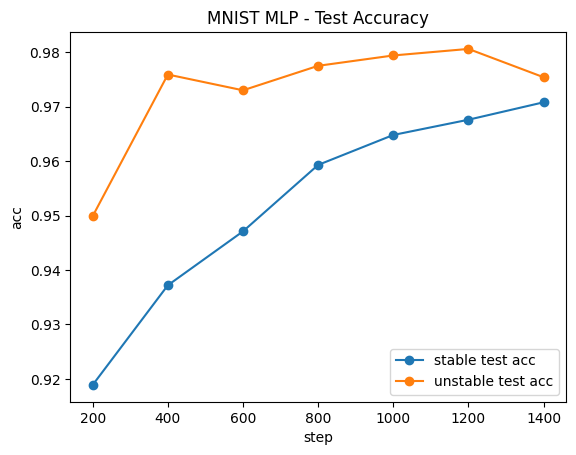

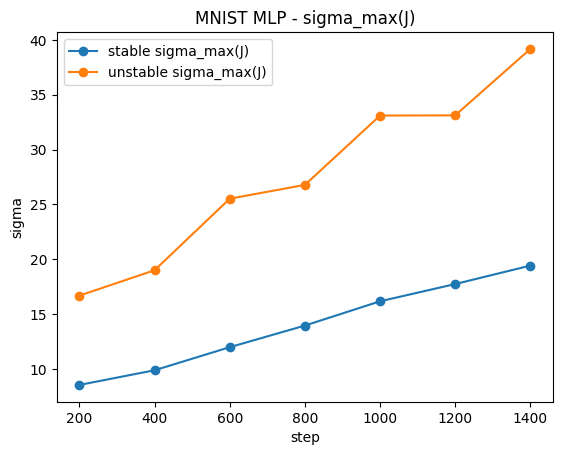

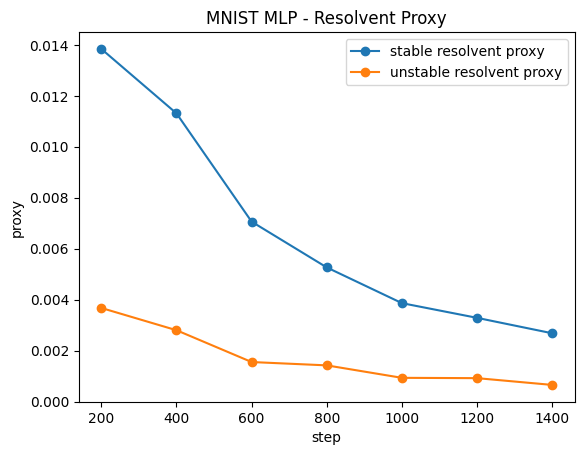

In [14]:
def plot_logs(logA, logB, title):
    plt.figure()
    plt.plot(logA["step"], logA["test_acc"], marker="o", label="stable test acc")
    plt.plot(logB["step"], logB["test_acc"], marker="o", label="unstable test acc")
    plt.title(title + " - Test Accuracy")
    plt.xlabel("step"); plt.ylabel("acc"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(logA["step"], logA["sigma"], marker="o", label="stable sigma_max(J)")
    plt.plot(logB["step"], logB["sigma"], marker="o", label="unstable sigma_max(J)")
    plt.title(title + " - sigma_max(J)")
    plt.xlabel("step"); plt.ylabel("sigma"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(logA["step"], logA["resolv"], marker="o", label="stable resolvent proxy")
    plt.plot(logB["step"], logB["resolv"], marker="o", label="unstable resolvent proxy")
    plt.title(title + " - Resolvent Proxy")
    plt.xlabel("step"); plt.ylabel("proxy"); plt.legend(); plt.show()

plot_logs(mnist_stable, mnist_unst, "MNIST MLP")

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sigma_band(logs, title="MNIST - sigma_max(J) with UQ"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["sigma_mean"])
    std   = np.array(logs["sigma_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean sigma")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("sigma_max(J)")
    plt.title(title)
    plt.legend()
    plt.show()

In [16]:
def plot_resolvent_band(logs, title="MNIST - Resolvent Proxy with UQ"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["res_mean"])
    std   = np.array(logs["res_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean resolvent proxy")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("resolvent proxy")
    plt.title(title)
    plt.legend()
    plt.show()

In [17]:
def plot_noise_entropy(logs, title="MNIST - Predictive Entropy Under Input Noise"):
    steps = np.array(logs["step"])
    ent   = np.array(logs["noise_ent"])

    plt.figure()
    plt.plot(steps, ent, marker="o")
    plt.xlabel("step")
    plt.ylabel("predictive entropy")
    plt.title(title)
    plt.show()

In [18]:
def plot_noise_accuracy(logs, title="MNIST - Accuracy Under Input Noise"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["noise_acc_mean"])
    std   = np.array(logs["noise_acc_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean noisy acc")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("accuracy under noise")
    plt.title(title)
    plt.legend()
    plt.show()

In [19]:
def plot_sigma_vs_entropy(logs, title="Sigma vs Predictive Entropy"):
    sigma = np.array(logs["sigma_mean"])
    ent   = np.array(logs["noise_ent"])

    plt.figure()
    plt.scatter(sigma, ent, s=80)
    plt.xlabel("sigma_max(J)")
    plt.ylabel("predictive entropy under noise")
    plt.title(title)
    plt.show()

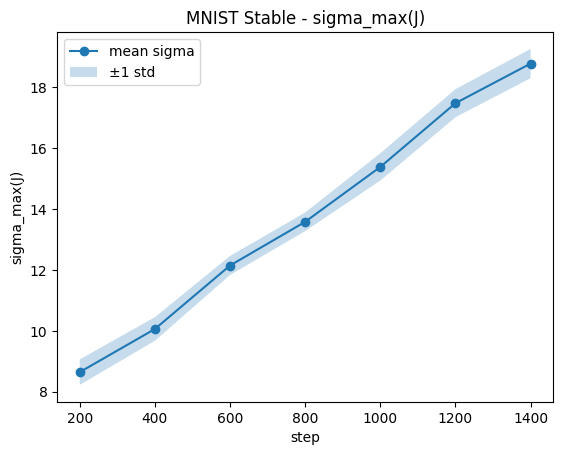

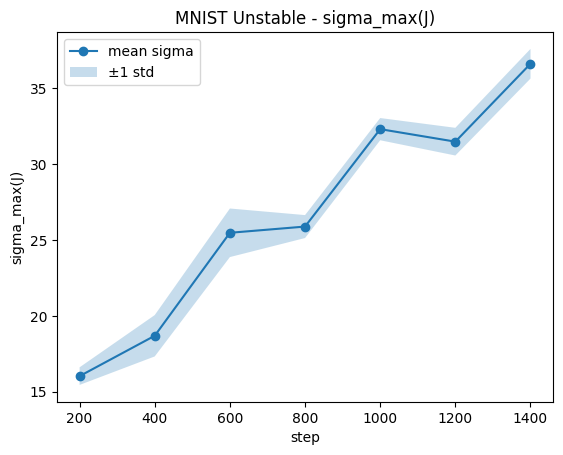

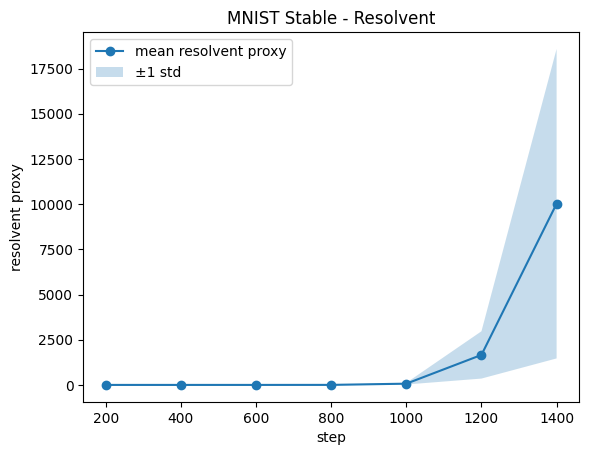

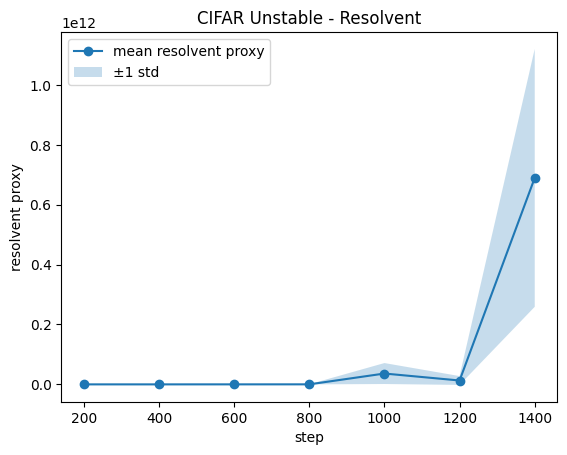

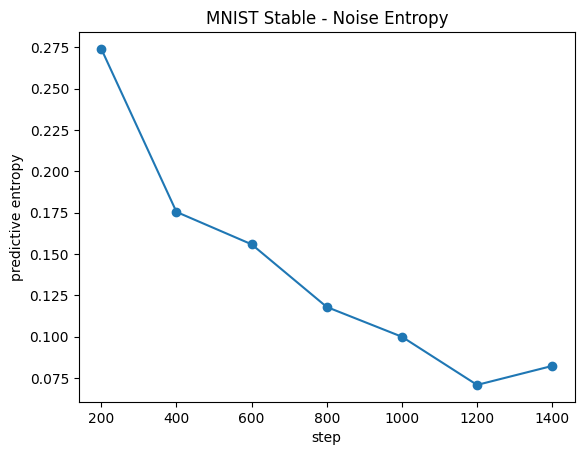

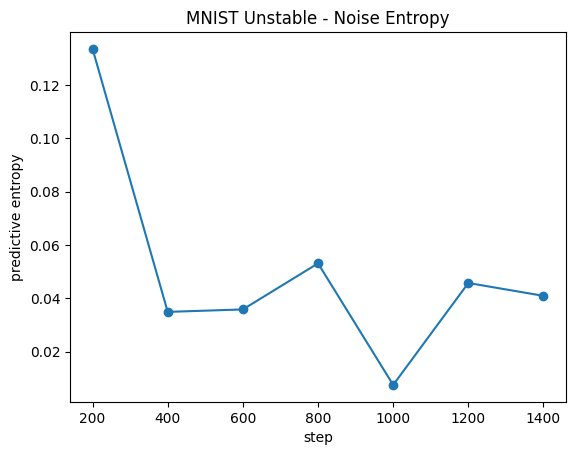

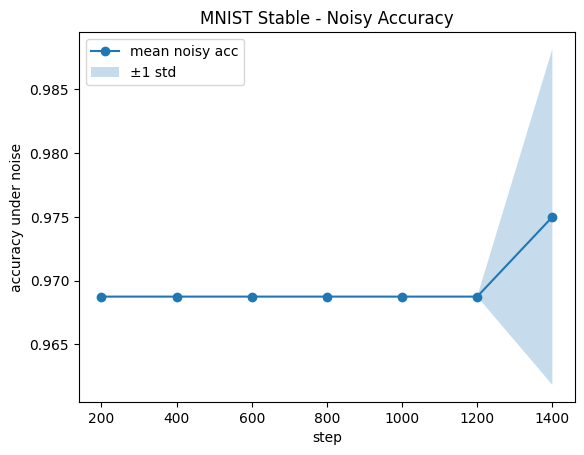

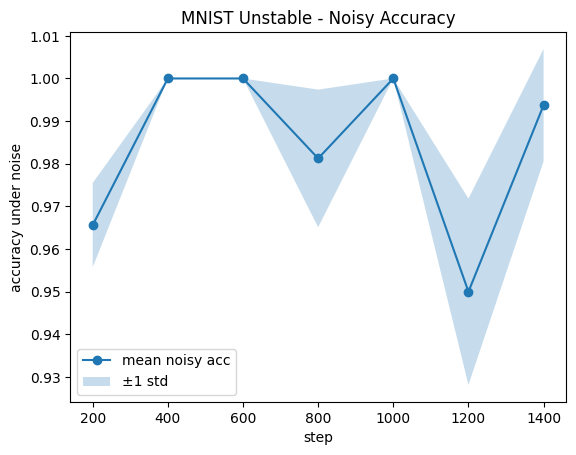

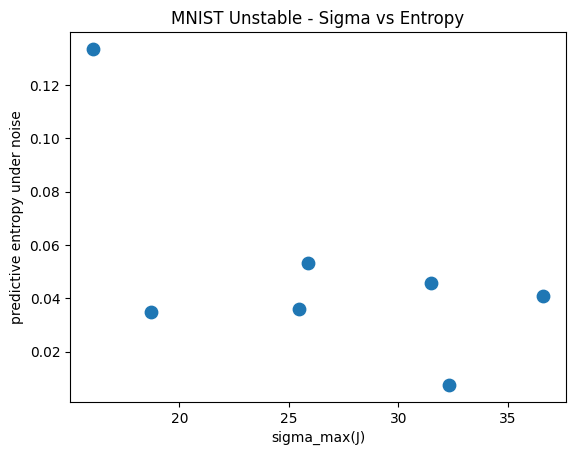

In [20]:
plot_sigma_band(mnist_stable, "MNIST Stable - sigma_max(J)")
plot_sigma_band(mnist_unst,   "MNIST Unstable - sigma_max(J)")

plot_resolvent_band(mnist_stable, "MNIST Stable - Resolvent")
plot_resolvent_band(mnist_unst,   "CIFAR Unstable - Resolvent")

plot_noise_entropy(mnist_stable, "MNIST Stable - Noise Entropy")
plot_noise_entropy(mnist_unst,   "MNIST Unstable - Noise Entropy")

plot_noise_accuracy(mnist_stable, "MNIST Stable - Noisy Accuracy")
plot_noise_accuracy(mnist_unst,   "MNIST Unstable - Noisy Accuracy")

plot_sigma_vs_entropy(mnist_unst, "MNIST Unstable - Sigma vs Entropy")

# Demo 2: CIFAR-10 + Small CNN

In [21]:
cifar_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_cifar = datasets.CIFAR10(root="./data", train=True, download=True, transform=cifar_tf)
test_cifar  = datasets.CIFAR10(root="./data", train=False, download=True, transform=cifar_tf)

train_loader_c = DataLoader(train_cifar, batch_size=256, shuffle=True, num_workers=0)
test_loader_c  = DataLoader(test_cifar, batch_size=256, shuffle=False, num_workers=0)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GELU(),
            nn.MaxPool2d(2),  # 16x16
            nn.Conv2d(64, 128, 3, padding=1), nn.GELU(),
            nn.MaxPool2d(2),  # 8x8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256), nn.GELU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

def f_logits_cnn(model, x):
    return model(x)  # [B,10]

In [22]:
@torch.no_grad()
def eval_acc_cifar(model, loader):
    model.eval()
    correct, total = 0, 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        pred = model(x).argmax(-1)
        correct += (pred==y).sum().item()
        total += y.numel()
    return correct/total

def train_run_cifar(tag, lr=3e-4, weight_decay=1e-2, steps=2000, diag_every=250):
    model = SmallCNN().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    #logs = {"step": [], "loss": [], "train_acc": [], "test_acc": [],  "grad_norm": [], "sigma": [], "resolv": []}
    logs = {
    "step": [], "loss": [], "train_acc": [], "test_acc": [], "grad_norm": [],

    # diagnostics (old)
    "sigma": [], "resolv": [],

    # diagnostics with uncertainty (new)
    "sigma_mean": [], "sigma_std": [],
    "res_mean": [], "res_std": [],

    # predictive UQ under input noise (new)
    "noise_ent": [],
    "noise_acc_mean": [], "noise_acc_std": [],
}

    it = iter(train_loader_c)
    for step in tqdm(range(1, steps+1), desc=f"CIFAR {tag}"):
        try:
            x,y = next(it)
        except StopIteration:
            it = iter(train_loader_c)
            x,y = next(it)

        x,y = x.to(device), y.to(device)
        model.train()
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters() if p.grad is not None)).item()
        opt.step()

        if step % diag_every == 0:
            train_acc = (logits.argmax(-1)==y).float().mean().item()
            test_acc = eval_acc_cifar(model, test_loader_c)

            xb,_ = next(iter(test_loader_c))
            xb = xb.to(device)[:32]   # smaller batch for JVP/VJP (CIFAR is heavier)
            sigma = sigma_max_jacobian(model, xb, f_logits_cnn, iters=10)
            resolv = resolvent_proxy_JTJ(model, xb, f_logits_cnn, alpha=max(10.0, sigma**2 + 1.0), K=15)

            logs["step"].append(step)
            logs["loss"].append(loss.item())
            logs["train_acc"].append(train_acc)
            logs["test_acc"].append(test_acc)
            logs["grad_norm"].append(grad_norm)
            logs["sigma"].append(sigma)
            logs["resolv"].append(resolv)

            xb, yb = next(iter(test_loader_c))
            xb, yb = xb.to(device)[:32], yb.to(device)[:32]

            # UQ-1: estimator uncertainty bands for diagnostics
            diag = diag_with_uncertainty(
                 model, test_loader_c, f_logits_cnn,
                 nbatches=5, nprobes=3, alpha=100.0,
                 sigma_iters=10, resolv_K=15, batch_cap=32)

            # UQ-3: predictive uncertainty under input noise
            ent = predictive_entropy_under_noise(model, xb, noise_std=0.05, nsamples=20)
            acc_mu, acc_sd = accuracy_under_noise(model, xb, yb, noise_std=0.05, nsamples=10)

            logs["sigma_mean"].append(diag["sigma_mean"])
            logs["sigma_std"].append(diag["sigma_std"])
            logs["res_mean"].append(diag["res_mean"])
            logs["res_std"].append(diag["res_std"])
            logs["noise_ent"].append(ent)
            logs["noise_acc_mean"].append(acc_mu)
            logs["noise_acc_std"].append(acc_sd)


            print(f"[{tag}] step={step} loss={loss.item():.3f} train_acc={train_acc:.3f} test_acc={test_acc:.3f} "
                  f"grad={grad_norm:.2e} sigma={sigma:.2f} resolv={resolv:.2f}")
    return model, logs

CIFAR stable:   0%|          | 0/2000 [00:00<?, ?it/s]

[stable] step=250 loss=1.288 train_acc=0.547 test_acc=0.530 grad=1.45e+00 sigma=2.26 resolv=0.10
[stable] step=500 loss=1.038 train_acc=0.668 test_acc=0.610 grad=1.55e+00 sigma=2.64 resolv=0.10
[stable] step=750 loss=0.906 train_acc=0.695 test_acc=0.657 grad=1.80e+00 sigma=3.64 resolv=0.07
[stable] step=1000 loss=0.625 train_acc=0.785 test_acc=0.684 grad=2.50e+00 sigma=4.83 resolv=0.04
[stable] step=1250 loss=0.786 train_acc=0.707 test_acc=0.693 grad=3.14e+00 sigma=5.74 resolv=0.03
[stable] step=1500 loss=0.393 train_acc=0.879 test_acc=0.708 grad=1.46e+00 sigma=6.93 resolv=0.02
[stable] step=1750 loss=0.264 train_acc=0.918 test_acc=0.712 grad=1.70e+00 sigma=7.91 resolv=0.02
[stable] step=2000 loss=0.125 train_acc=0.973 test_acc=0.714 grad=1.86e+00 sigma=9.91 resolv=0.01


CIFAR unstable:   0%|          | 0/2000 [00:00<?, ?it/s]

[unstable] step=250 loss=0.901 train_acc=0.676 test_acc=0.676 grad=1.64e+00 sigma=5.76 resolv=0.03
[unstable] step=500 loss=0.523 train_acc=0.828 test_acc=0.733 grad=1.37e+00 sigma=11.52 resolv=0.01
[unstable] step=750 loss=0.372 train_acc=0.852 test_acc=0.751 grad=1.30e+00 sigma=17.19 resolv=0.00
[unstable] step=1000 loss=0.064 train_acc=0.984 test_acc=0.749 grad=6.48e-01 sigma=24.31 resolv=0.00
[unstable] step=1250 loss=0.077 train_acc=0.980 test_acc=0.757 grad=9.68e-01 sigma=29.86 resolv=0.00
[unstable] step=1500 loss=0.034 train_acc=0.984 test_acc=0.754 grad=9.03e-01 sigma=34.65 resolv=0.00
[unstable] step=1750 loss=0.038 train_acc=0.988 test_acc=0.753 grad=7.89e-01 sigma=41.09 resolv=0.00
[unstable] step=2000 loss=0.068 train_acc=0.969 test_acc=0.751 grad=1.15e+00 sigma=42.83 resolv=0.00


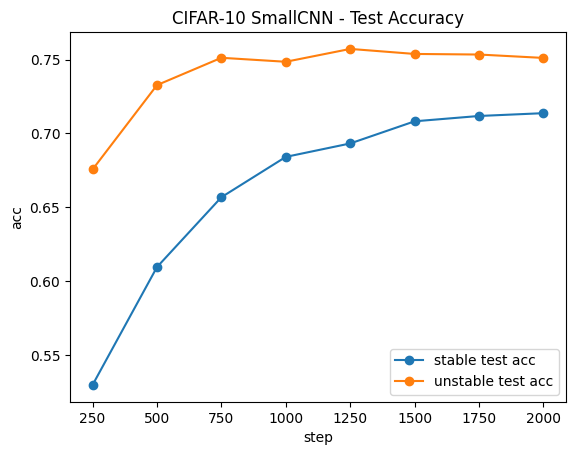

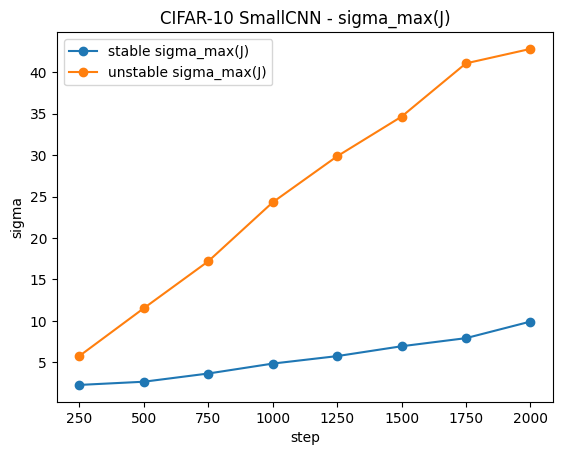

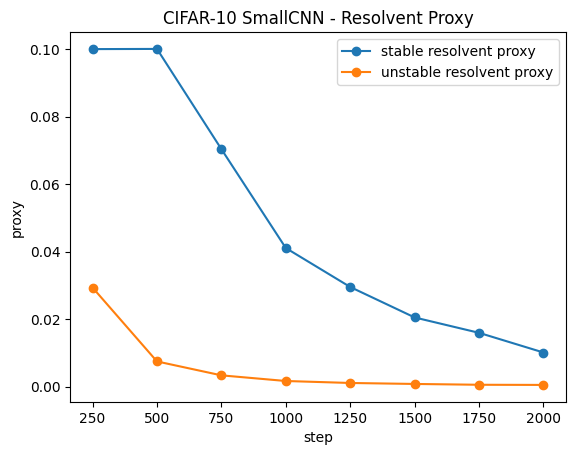

In [23]:
cifar_stable_model, cifar_stable = train_run_cifar("stable", lr=3e-4, weight_decay=1e-2, steps=2000, diag_every=250)
cifar_unst_model, cifar_unst   = train_run_cifar("unstable", lr=2e-3, weight_decay=0.0, steps=2000, diag_every=250)
plot_logs(cifar_stable, cifar_unst, "CIFAR-10 SmallCNN")

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sigma_band(logs, title="CIFAR - sigma_max(J) with UQ"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["sigma_mean"])
    std   = np.array(logs["sigma_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean sigma")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("sigma_max(J)")
    plt.title(title)
    plt.legend()
    plt.show()

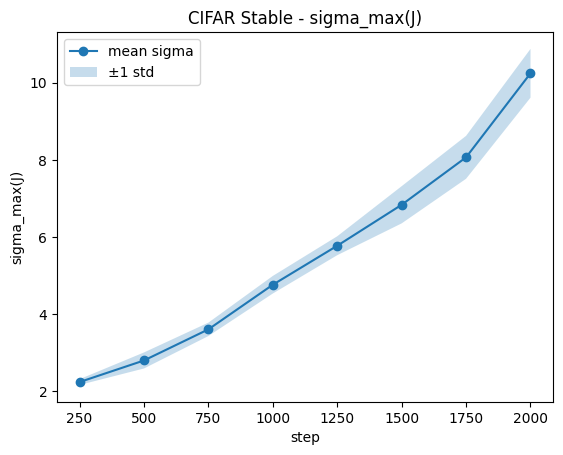

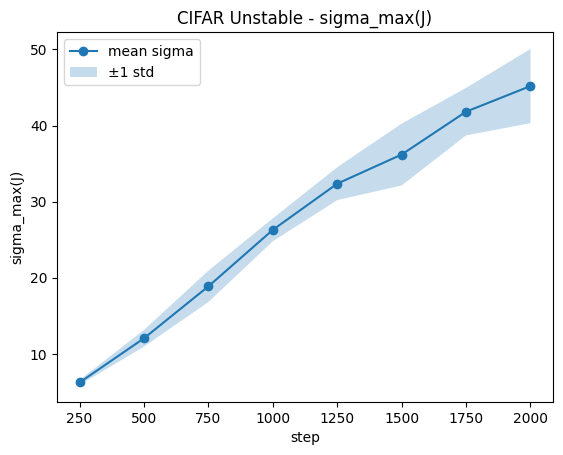

In [25]:
plot_sigma_band(cifar_stable, "CIFAR Stable - sigma_max(J)")
plot_sigma_band(cifar_unst,   "CIFAR Unstable - sigma_max(J)")

In [26]:
def plot_resolvent_band(logs, title="CIFAR - Resolvent Proxy with UQ"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["res_mean"])
    std   = np.array(logs["res_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean resolvent proxy")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("resolvent proxy")
    plt.title(title)
    plt.legend()
    plt.show()

In [27]:
def plot_noise_entropy(logs, title="CIFAR - Predictive Entropy Under Input Noise"):
    steps = np.array(logs["step"])
    ent   = np.array(logs["noise_ent"])

    plt.figure()
    plt.plot(steps, ent, marker="o")
    plt.xlabel("step")
    plt.ylabel("predictive entropy")
    plt.title(title)
    plt.show()

In [28]:
def plot_noise_accuracy(logs, title="CIFAR - Accuracy Under Input Noise"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["noise_acc_mean"])
    std   = np.array(logs["noise_acc_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean noisy acc")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("accuracy under noise")
    plt.title(title)
    plt.legend()
    plt.show()

In [29]:
def plot_sigma_vs_entropy(logs, title="Sigma vs Predictive Entropy"):
    sigma = np.array(logs["sigma_mean"])
    ent   = np.array(logs["noise_ent"])

    plt.figure()
    plt.scatter(sigma, ent, s=80)
    plt.xlabel("sigma_max(J)")
    plt.ylabel("predictive entropy under noise")
    plt.title(title)
    plt.show()

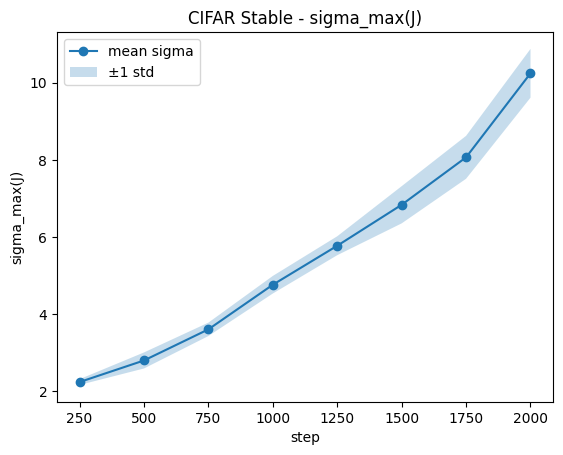

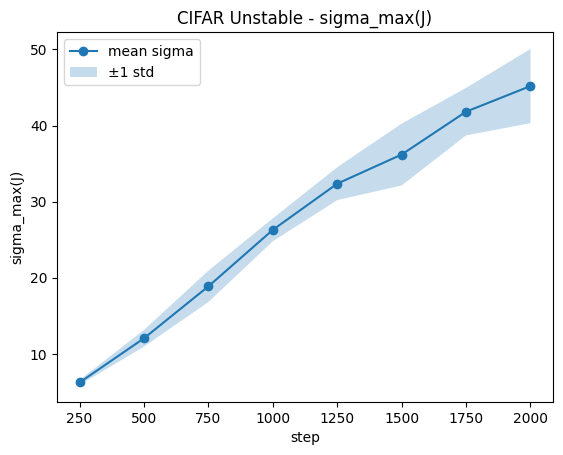

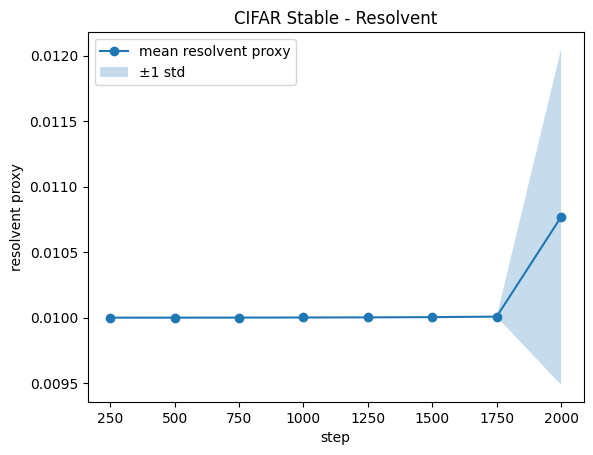

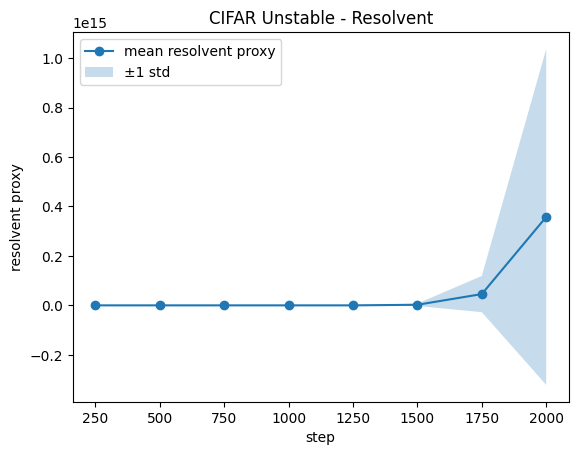

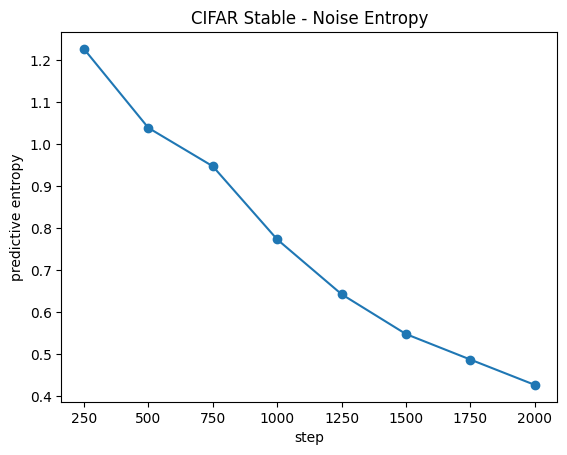

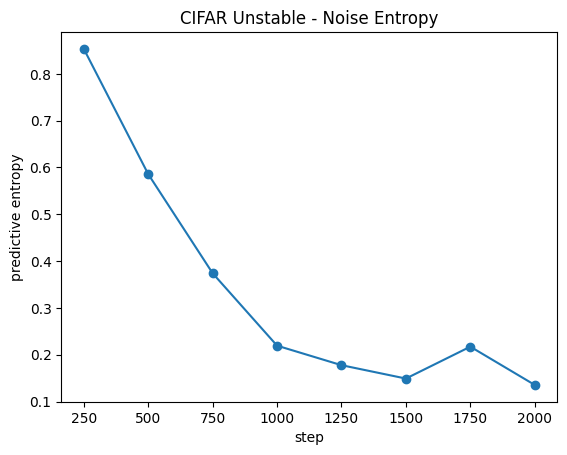

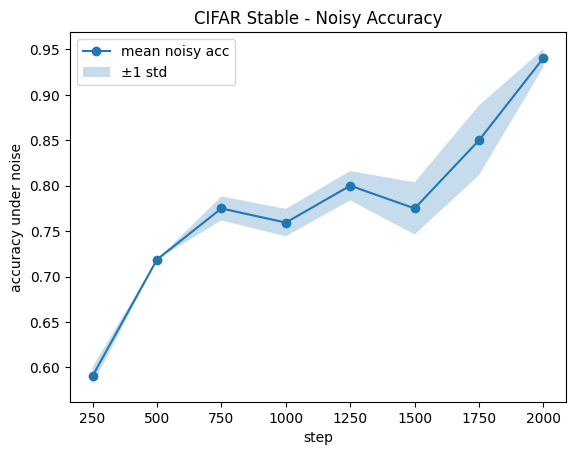

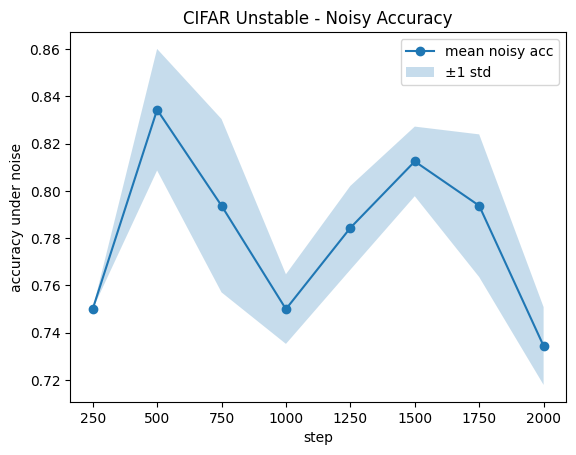

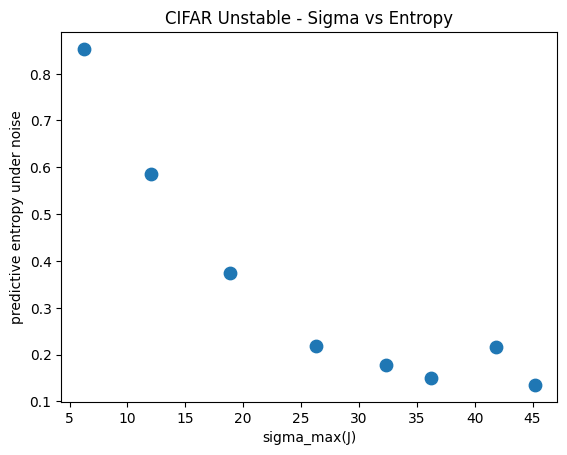

In [30]:
plot_sigma_band(cifar_stable, "CIFAR Stable - sigma_max(J)")
plot_sigma_band(cifar_unst,   "CIFAR Unstable - sigma_max(J)")

plot_resolvent_band(cifar_stable, "CIFAR Stable - Resolvent")
plot_resolvent_band(cifar_unst,   "CIFAR Unstable - Resolvent")

plot_noise_entropy(cifar_stable, "CIFAR Stable - Noise Entropy")
plot_noise_entropy(cifar_unst,   "CIFAR Unstable - Noise Entropy")

plot_noise_accuracy(cifar_stable, "CIFAR Stable - Noisy Accuracy")
plot_noise_accuracy(cifar_unst,   "CIFAR Unstable - Noisy Accuracy")

plot_sigma_vs_entropy(cifar_unst, "CIFAR Unstable - Sigma vs Entropy")

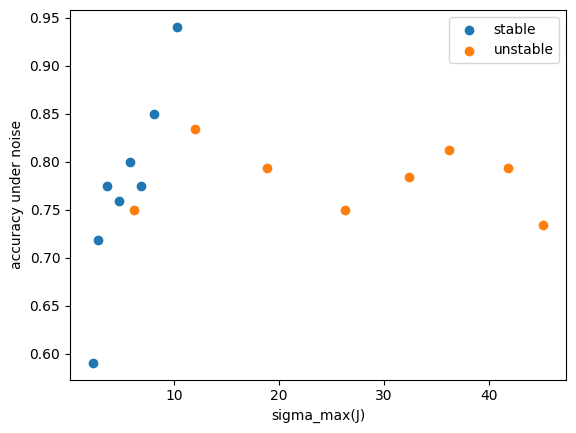

In [31]:
plt.scatter(cifar_stable["sigma_mean"], cifar_stable["noise_acc_mean"], label="stable")
plt.scatter(cifar_unst["sigma_mean"], cifar_unst["noise_acc_mean"], label="unstable")
plt.xlabel("sigma_max(J)")
plt.ylabel("accuracy under noise")
plt.legend()
plt.show()

# Demo-3 CIFAR-10C

In [32]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

CIFAR10C_CORRUPTIONS = [
    "gaussian_noise","shot_noise","impulse_noise",
    "defocus_blur","glass_blur","motion_blur","zoom_blur",
    "snow","frost","fog","brightness",
    "contrast","elastic_transform","pixelate","jpeg_compression",
]

class CIFAR10CDataset(Dataset):
    """
    Loads a single corruption at a single severity from CIFAR-10-C (npy files).
    """
    def __init__(self, root, corruption, severity=1, transform=None):
        assert 1 <= severity <= 5
        self.root = root
        self.corruption = corruption
        self.severity = severity
        self.transform = transform

        labels_path = os.path.join(root, "labels.npy")
        data_path = os.path.join(root, f"{corruption}.npy")

        self.labels = np.load(labels_path)              # [50000]
        data = np.load(data_path)                       # [50000,32,32,3], uint8

        # select severity slice
        start = (severity - 1) * 10000
        end = severity * 10000
        self.data = data[start:end]
        self.labels = self.labels[start:end]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx]          # uint8 HWC
        y = int(self.labels[idx])

        # convert to float tensor CHW in [0,1]
        x = torch.from_numpy(x).permute(2,0,1).float() / 255.0

        if self.transform is not None:
            x = self.transform(x)

        return x, y

In [33]:
import torchvision.transforms as T
cifar_norm = T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))

def apply_norm(x):
    return cifar_norm(x)

In [34]:
@torch.no_grad()
def eval_acc_on_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    for x,y in loader:
        x = x.to(device)
        y = torch.as_tensor(y, device=device)
        pred = model(x).argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total

@torch.no_grad()
def eval_cifar10c(model, c10c_root, severity=5, corruptions=None, batch_size=256):
    """
    Returns mean accuracy across corruption types for a fixed severity.
    Also returns std across corruption types (useful UQ).
    """
    if corruptions is None:
        corruptions = CIFAR10C_CORRUPTIONS

    accs = []
    for corr in corruptions:
        ds = CIFAR10CDataset(c10c_root, corr, severity=severity, transform=apply_norm)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        accs.append(eval_acc_on_loader(model, dl))

    accs = np.array(accs, dtype=float)
    return float(accs.mean()), float(accs.std(ddof=1))

In [35]:
C10C_ROOT = "/path/to/CIFAR-10-C"

In [36]:
import os

C10C_ROOT = "/your/real/path/to/CIFAR-10-C"  # change this

print("Folder exists:", os.path.exists(C10C_ROOT))
print("Files inside:")
print(os.listdir(C10C_ROOT))

Folder exists: False
Files inside:


FileNotFoundError: [Errno 2] No such file or directory: '/your/real/path/to/CIFAR-10-C'

In [37]:
import os
import tarfile
import urllib.request

# ---- Configure download location ----
DATA_DIR = os.path.abspath("./data")
os.makedirs(DATA_DIR, exist_ok=True)

C10C_TAR = os.path.join(DATA_DIR, "CIFAR-10-C.tar")
C10C_ROOT = os.path.join(DATA_DIR, "CIFAR-10-C")

# ---- Zenodo direct download link ----
URL = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar?download=1"

# ---- Download if not already present ----
if not os.path.exists(C10C_TAR):
    print("Downloading CIFAR-10-C...")
    urllib.request.urlretrieve(URL, C10C_TAR)
    print("Download complete.")
else:
    print("Tar file already exists.")

# ---- Extract if not already extracted ----
if not os.path.exists(C10C_ROOT):
    print("Extracting CIFAR-10-C...")
    with tarfile.open(C10C_TAR) as tar:
        tar.extractall(DATA_DIR)
    print("Extraction complete.")
else:
    print("Already extracted.")

# ---- Verify ----
print("\nVerification:")
print("C10C_ROOT exists:", os.path.exists(C10C_ROOT))
print("labels.npy exists:", os.path.exists(os.path.join(C10C_ROOT, "labels.npy")))

Tar file already exists.
Already extracted.

Verification:
C10C_ROOT exists: True
labels.npy exists: True


In [38]:
import os

print(os.listdir("."))   # current notebook directory

['fig', 'pseudoSpect_ModelStability.ipynb', 'data']


In [39]:
C10C_ROOT = os.path.abspath("./data/CIFAR-10-C")

In [40]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Standard CIFAR-10-C corruption list
CIFAR10C_CORRUPTIONS = [
    "gaussian_noise","shot_noise","impulse_noise",
    "defocus_blur","glass_blur","motion_blur","zoom_blur",
    "snow","frost","fog","brightness",
    "contrast","elastic_transform","pixelate","jpeg_compression",
]

class CIFAR10CDataset(Dataset):
    """
    Loads a single corruption at a single severity from CIFAR-10-C .npy files.
    Each corruption has 50000 images arranged as 5 severities * 10000 each.
    """
    def __init__(self, root, corruption, severity=3, transform=None):
        assert 1 <= severity <= 5
        self.root = root
        self.corruption = corruption
        self.severity = severity
        self.transform = transform

        labels_path = os.path.join(root, "labels.npy")
        data_path   = os.path.join(root, f"{corruption}.npy")

        if not os.path.exists(labels_path):
            raise FileNotFoundError(f"Missing labels.npy at {labels_path}")
        if not os.path.exists(data_path):
            raise FileNotFoundError(f"Missing {corruption}.npy at {data_path}")

        labels = np.load(labels_path)   # [50000]
        data   = np.load(data_path)     # [50000,32,32,3] uint8

        start = (severity - 1) * 10000
        end   = severity * 10000
        self.labels = labels[start:end]
        self.data   = data[start:end]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.data[idx]  # HWC uint8
        y = int(self.labels[idx])

        # to float tensor CHW in [0,1]
        x = torch.from_numpy(x).permute(2,0,1).float() / 255.0

        if self.transform is not None:
            x = self.transform(x)

        return x, y


@torch.no_grad()
def eval_acc_on_loader(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x = x.to(device)
        y = torch.as_tensor(y, device=device)
        pred = model(x).argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.numel()
    return correct / total


@torch.no_grad()
def eval_cifar10c(model, c10c_root, device, transform,
                 severity=5, corruptions=None, batch_size=256):
    """
    Mean & std accuracy across corruption types for a fixed severity.
    """
    if corruptions is None:
        corruptions = CIFAR10C_CORRUPTIONS

    accs = []
    for corr in corruptions:
        ds = CIFAR10CDataset(c10c_root, corr, severity=severity, transform=transform)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        accs.append(eval_acc_on_loader(model, dl, device))

    accs = np.array(accs, dtype=float)
    return float(accs.mean()), float(accs.std(ddof=1))

In [41]:
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def train_run_cifar_demo3(
    tag: str,
    c10c_root: str,
    model_ctor,
    f_fn,
    train_loader,
    test_loader,
    device,
    lr=3e-4,
    weight_decay=1e-2,
    steps=2000,
    diag_every=250,
    # UQ settings
    uq_nbatches=5,
    uq_nprobes=3,
    sigma_iters=10,
    resolv_K=15,
    resolv_alpha=100.0,   # IMPORTANT: keep fixed across runs for comparability
    # input-noise UQ
    noise_std=0.05,
    noise_nsamples_ent=20,
    noise_nsamples_acc=10,
    # CIFAR-10-C
    c10c_severity=5,
    c10c_corruptions=None,
    c10c_batch_size=256,
    # speed
    diag_batch_cap=32,
):
    model = model_ctor().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # log dict (coherent, everything you need)
    logs = {
        "step": [], "loss": [], "train_acc": [], "test_acc": [], "grad_norm": [],

        # operator diagnostics w/ UQ
        "sigma_mean": [], "sigma_std": [],
        "res_mean": [], "res_std": [],

        # input-noise predictive UQ
        "noise_ent": [],
        "noise_acc_mean": [], "noise_acc_std": [],

        # CIFAR-10-C robustness UQ across corruption types
        "c10c_acc_mean": [], "c10c_acc_std": [],
    }

    it = iter(train_loader)

    for step in tqdm(range(1, steps + 1), desc=f"Demo-3 CIFAR {tag}"):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y = next(it)

        x, y = x.to(device), y.to(device)

        model.train()
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad(set_to_none=True)
        loss.backward()

        # grad norm (global)
        grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters() if p.grad is not None)).item()
        opt.step()

        if step % diag_every == 0:
            # quick in-batch train acc
            train_acc = (logits.argmax(-1) == y).float().mean().item()

            # clean test accuracy
            test_acc = eval_acc_on_loader(model, test_loader, device)

            # pick a fixed test batch for diagnostics and noise UQ
            xb, yb = next(iter(test_loader))
            xb, yb = xb.to(device)[:diag_batch_cap], yb.to(device)[:diag_batch_cap]

            # --- UQ-1: diagnostic bands (batch/probe bootstrap) ---
            diag = diag_with_uncertainty(
                model, test_loader, f_fn,
                nbatches=uq_nbatches, nprobes=uq_nprobes,
                alpha=resolv_alpha,
                sigma_iters=sigma_iters, resolv_K=resolv_K,
                batch_cap=diag_batch_cap
            )

            # --- UQ-3: predictive uncertainty under input noise ---
            ent = predictive_entropy_under_noise(model, xb, noise_std=noise_std, nsamples=noise_nsamples_ent)
            nacc_mu, nacc_sd = accuracy_under_noise(model, xb, yb, noise_std=noise_std, nsamples=noise_nsamples_acc)

            # --- Demo-3: CIFAR-10-C robustness (mean±std over corruption types) ---
            c10c_mu, c10c_sd = eval_cifar10c(
                model,
                c10c_root=c10c_root,
                device=device,
                transform=apply_norm,   # same normalization as CIFAR-10 training
                severity=c10c_severity,
                corruptions=c10c_corruptions,  # None -> uses full list
                batch_size=c10c_batch_size,
            )

            # store logs
            logs["step"].append(step)
            logs["loss"].append(float(loss.item()))
            logs["train_acc"].append(train_acc)
            logs["test_acc"].append(test_acc)
            logs["grad_norm"].append(float(grad_norm))

            logs["sigma_mean"].append(diag["sigma_mean"])
            logs["sigma_std"].append(diag["sigma_std"])
            logs["res_mean"].append(diag["res_mean"])
            logs["res_std"].append(diag["res_std"])
            #logs["sigma"].append(diag["sigma_mean"])
            #logs["resolv"].append(diag["res_mean"])

            logs["noise_ent"].append(ent)
            logs["noise_acc_mean"].append(nacc_mu)
            logs["noise_acc_std"].append(nacc_sd)

            logs["c10c_acc_mean"].append(c10c_mu)
            logs["c10c_acc_std"].append(c10c_sd)

            print(
                f"[{tag}] step={step} "
                f"loss={loss.item():.3f} train_acc={train_acc:.3f} test_acc={test_acc:.3f} "
                f"grad={grad_norm:.2e} "
                f"sigma={diag['sigma_mean']:.2f}±{diag['sigma_std']:.2f} "
                f"res={diag['res_mean']:.4f}±{diag['res_std']:.4f} "
                f"noisy_acc={nacc_mu:.3f}±{nacc_sd:.3f} ent={ent:.3f} "
                f"c10c(sev{c10c_severity})={c10c_mu:.3f}±{c10c_sd:.3f}"
            )

    return model, logs

In [42]:
C10C_ROOT = os.path.abspath("./data/CIFAR-10-C")

# Stable run
cifar_demo3_stable_model, cifar_demo3_stable = train_run_cifar_demo3(
    tag="stable",
    c10c_root=C10C_ROOT,
    model_ctor=SmallCNN,
    f_fn=f_logits_cnn,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    device=device,
    lr=3e-4,
    weight_decay=1e-2,
    steps=2000,
    diag_every=250,
    resolv_alpha=100.0,
    c10c_severity=5,
)

# Unstable run
cifar_demo3_unst_model, cifar_demo3_unst = train_run_cifar_demo3(
    tag="unstable",
    c10c_root=C10C_ROOT,
    model_ctor=SmallCNN,
    f_fn=f_logits_cnn,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    device=device,
    lr=2e-3,
    weight_decay=0.0,
    steps=2000,
    diag_every=250,
    resolv_alpha=100.0,
    c10c_severity=5,
)

Demo-3 CIFAR stable:   0%|          | 0/2000 [00:00<?, ?it/s]

[stable] step=250 loss=1.260 train_acc=0.547 test_acc=0.553 grad=1.28e+00 sigma=2.23±0.15 res=0.0100±0.0000 noisy_acc=0.653±0.010 ent=1.247 c10c(sev5)=0.447±0.101
[stable] step=500 loss=1.022 train_acc=0.660 test_acc=0.623 grad=1.50e+00 sigma=2.92±0.10 res=0.0100±0.0000 noisy_acc=0.666±0.015 ent=1.094 c10c(sev5)=0.485±0.121
[stable] step=750 loss=0.792 train_acc=0.734 test_acc=0.668 grad=1.58e+00 sigma=3.89±0.17 res=0.0100±0.0000 noisy_acc=0.688±0.029 ent=0.929 c10c(sev5)=0.514±0.130
[stable] step=1000 loss=0.605 train_acc=0.785 test_acc=0.693 grad=1.39e+00 sigma=5.37±0.34 res=0.0100±0.0000 noisy_acc=0.838±0.013 ent=0.754 c10c(sev5)=0.540±0.127
[stable] step=1250 loss=0.534 train_acc=0.809 test_acc=0.708 grad=2.33e+00 sigma=7.06±0.46 res=0.0100±0.0000 noisy_acc=0.812±0.029 ent=0.645 c10c(sev5)=0.554±0.125
[stable] step=1500 loss=0.437 train_acc=0.855 test_acc=0.710 grad=1.91e+00 sigma=8.33±0.33 res=0.0100±0.0000 noisy_acc=0.809±0.010 ent=0.586 c10c(sev5)=0.547±0.125
[stable] step=1750 

Demo-3 CIFAR unstable:   0%|          | 0/2000 [00:00<?, ?it/s]

[unstable] step=250 loss=0.865 train_acc=0.684 test_acc=0.670 grad=1.41e+00 sigma=5.88±0.61 res=0.0100±0.0000 noisy_acc=0.713±0.020 ent=0.869 c10c(sev5)=0.502±0.111
[unstable] step=500 loss=0.582 train_acc=0.805 test_acc=0.736 grad=1.75e+00 sigma=11.76±0.84 res=0.0306±0.0270 noisy_acc=0.709±0.015 ent=0.557 c10c(sev5)=0.536±0.111
[unstable] step=750 loss=0.310 train_acc=0.891 test_acc=0.746 grad=1.27e+00 sigma=16.68±1.40 res=651.4527±1663.2796 noisy_acc=0.769±0.016 ent=0.323 c10c(sev5)=0.544±0.117
[unstable] step=1000 loss=0.055 train_acc=0.980 test_acc=0.750 grad=9.37e-01 sigma=26.24±2.55 res=254069817.9333±443524693.8735 noisy_acc=0.747±0.023 ent=0.264 c10c(sev5)=0.547±0.117
[unstable] step=1250 loss=0.072 train_acc=0.977 test_acc=0.748 grad=1.03e+00 sigma=29.34±2.42 res=1996591157.0667±2033741652.7809 noisy_acc=0.756±0.020 ent=0.163 c10c(sev5)=0.549±0.123
[unstable] step=1500 loss=0.044 train_acc=0.988 test_acc=0.747 grad=8.52e-01 sigma=35.75±3.59 res=500367438045.8666±880686690469.5

# Use a Demo-3 plotting function that matches your keys

In [43]:
import numpy as np
import matplotlib.pyplot as plt

def plot_logs_demo3(log_stable, log_unst, title):
    # 1) Test accuracy
    plt.figure()
    plt.plot(log_stable["step"], log_stable["test_acc"], marker="o", label="stable test acc")
    plt.plot(log_unst["step"],   log_unst["test_acc"],   marker="o", label="unstable test acc")
    plt.title(title + " - Test Accuracy")
    plt.xlabel("step"); plt.ylabel("acc"); plt.legend(); plt.show()

    # 2) sigma_max(J) with bands
    def bandplot(logs, key_mean, key_std, label, ylabel):
        steps = np.array(logs["step"])
        mean  = np.array(logs[key_mean])
        std   = np.array(logs[key_std])
        plt.plot(steps, mean, marker="o", label=label)
        plt.fill_between(steps, mean-std, mean+std, alpha=0.2)

    plt.figure()
    bandplot(log_stable, "sigma_mean", "sigma_std", "stable sigma_mean ± std", "sigma_max(J)")
    bandplot(log_unst,   "sigma_mean", "sigma_std", "unstable sigma_mean ± std", "sigma_max(J)")
    plt.title(title + " - sigma_max(J) with UQ")
    plt.xlabel("step"); plt.ylabel("sigma_max(J)"); plt.legend(); plt.show()

    # 3) resolvent proxy with bands
    plt.figure()
    bandplot(log_stable, "res_mean", "res_std", "stable resolvent ± std", "resolvent proxy")
    bandplot(log_unst,   "res_mean", "res_std", "unstable resolvent ± std", "resolvent proxy")
    plt.title(title + " - Resolvent Proxy with UQ")
    plt.xlabel("step"); plt.ylabel("resolvent proxy"); plt.legend(); plt.show()

    # 4) Noisy accuracy with bands
    plt.figure()
    bandplot(log_stable, "noise_acc_mean", "noise_acc_std", "stable noisy acc ± std", "acc under noise")
    bandplot(log_unst,   "noise_acc_mean", "noise_acc_std", "unstable noisy acc ± std", "acc under noise")
    plt.title(title + " - Accuracy Under Noise with UQ")
    plt.xlabel("step"); plt.ylabel("acc under noise"); plt.legend(); plt.show()

    # 5) CIFAR-10-C accuracy with bands (Demo-3 headline)
    plt.figure()
    bandplot(log_stable, "c10c_acc_mean", "c10c_acc_std", "stable C10-C acc ± std", "CIFAR-10-C acc")
    bandplot(log_unst,   "c10c_acc_mean", "c10c_acc_std", "unstable C10-C acc ± std", "CIFAR-10-C acc")
    plt.title(title + " - CIFAR-10-C Robustness (severity fixed)")
    plt.xlabel("step"); plt.ylabel("CIFAR-10-C acc"); plt.legend(); plt.show()

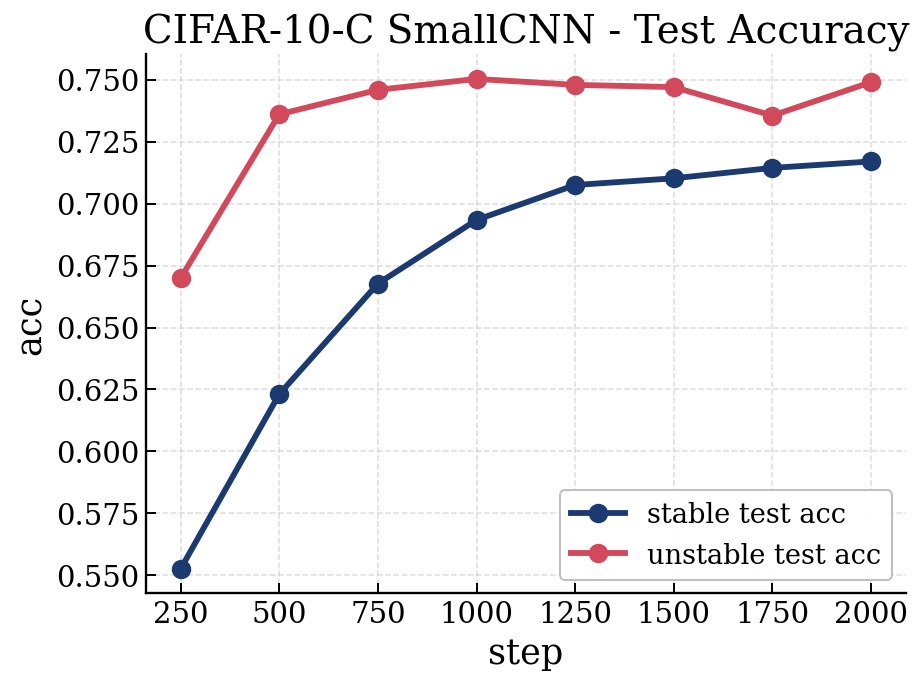

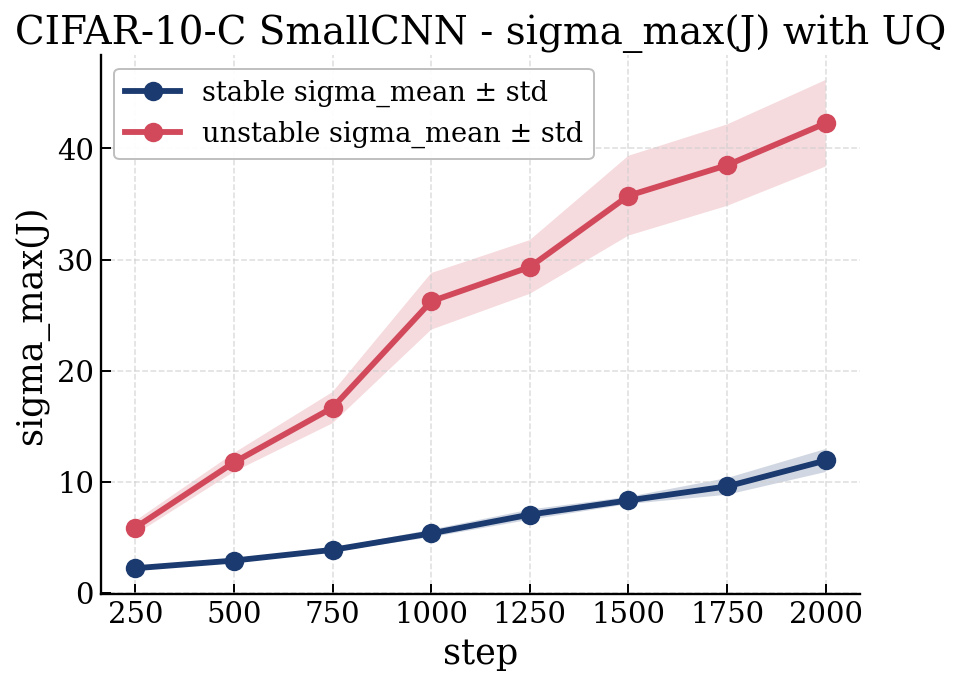

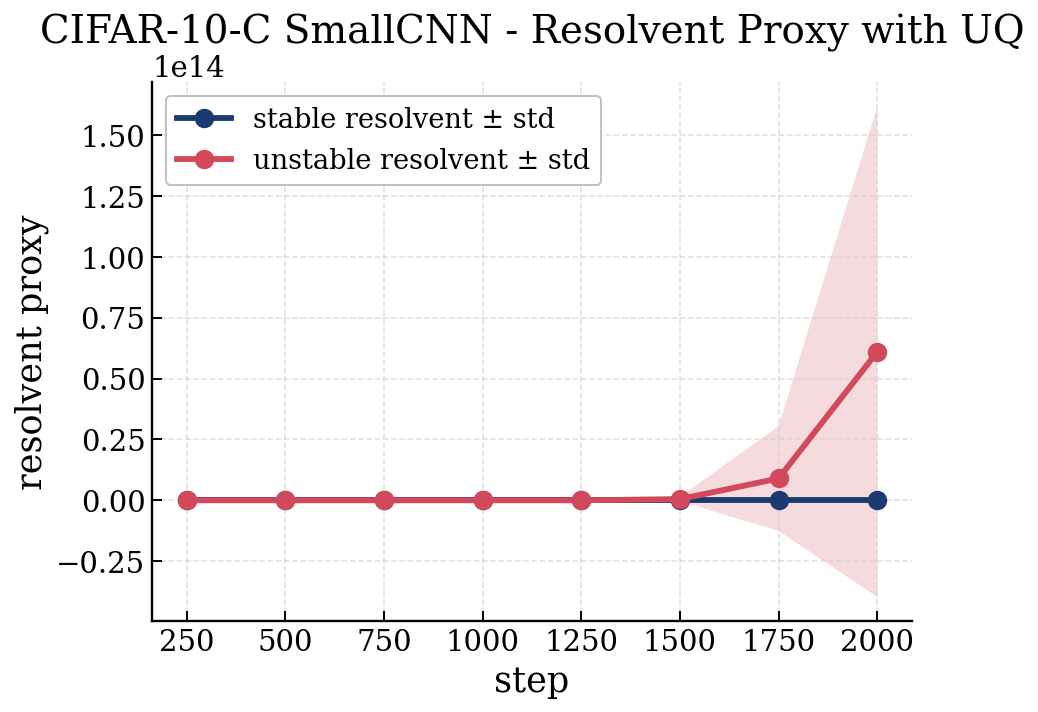

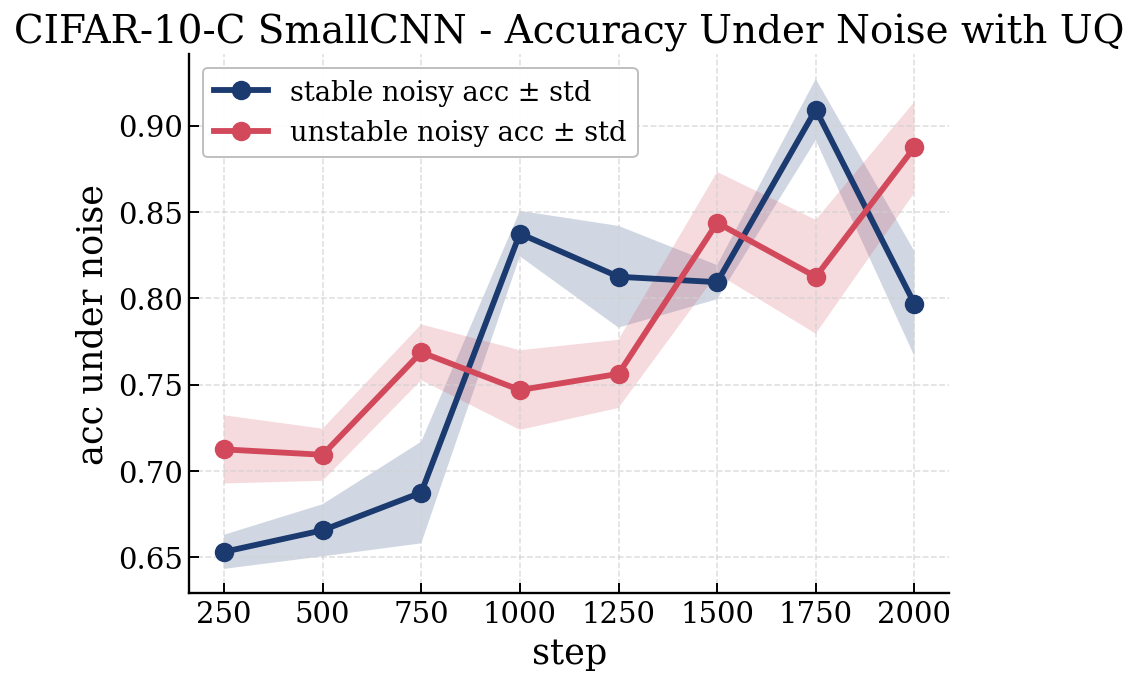

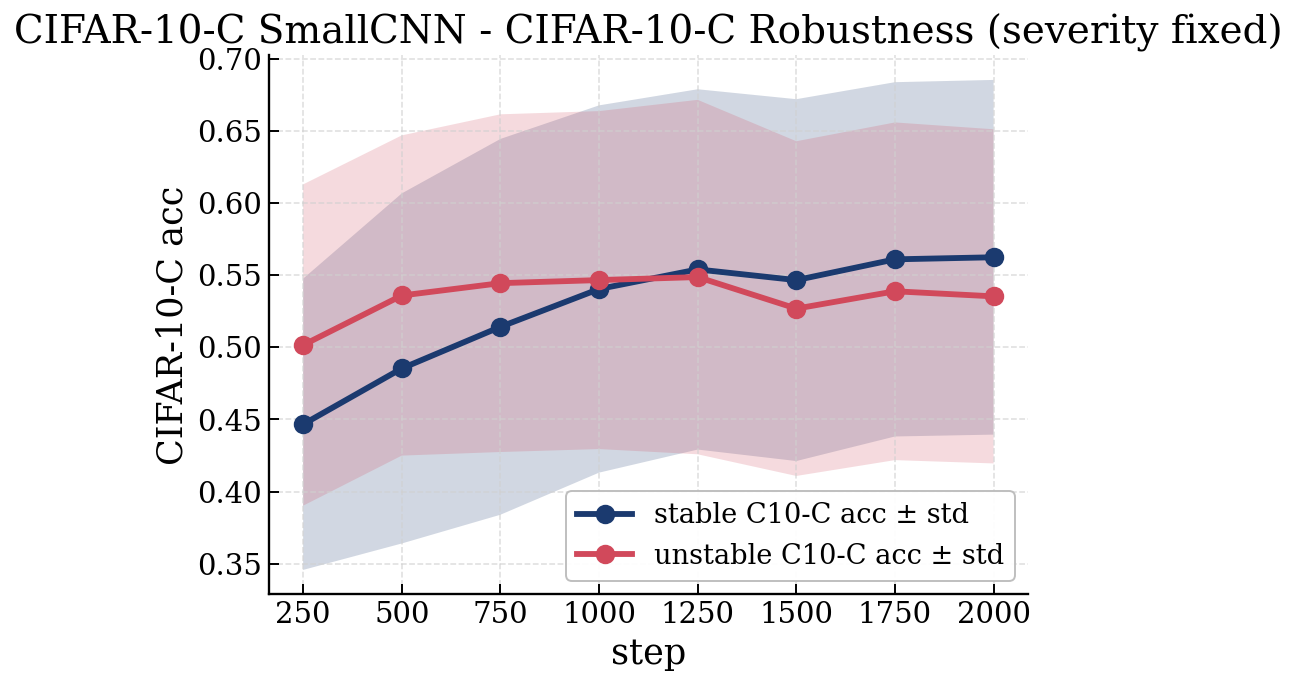

In [100]:
plot_logs_demo3(cifar_demo3_stable, cifar_demo3_unst, "CIFAR-10-C SmallCNN")

In [44]:
import numpy as np
import matplotlib.pyplot as plt

def plot_sigma_band(logs, title="CIFAR-10C - sigma_max(J) with UQ"):
    steps = np.array(logs["step"])
    mean  = np.array(logs["sigma_mean"])
    std   = np.array(logs["sigma_std"])

    plt.figure()
    plt.plot(steps, mean, marker="o", label="mean sigma")
    plt.fill_between(steps, mean-std, mean+std, alpha=0.25, label="±1 std")
    plt.xlabel("step")
    plt.ylabel("sigma_max(J)")
    plt.title(title)
    plt.legend()
    plt.show()

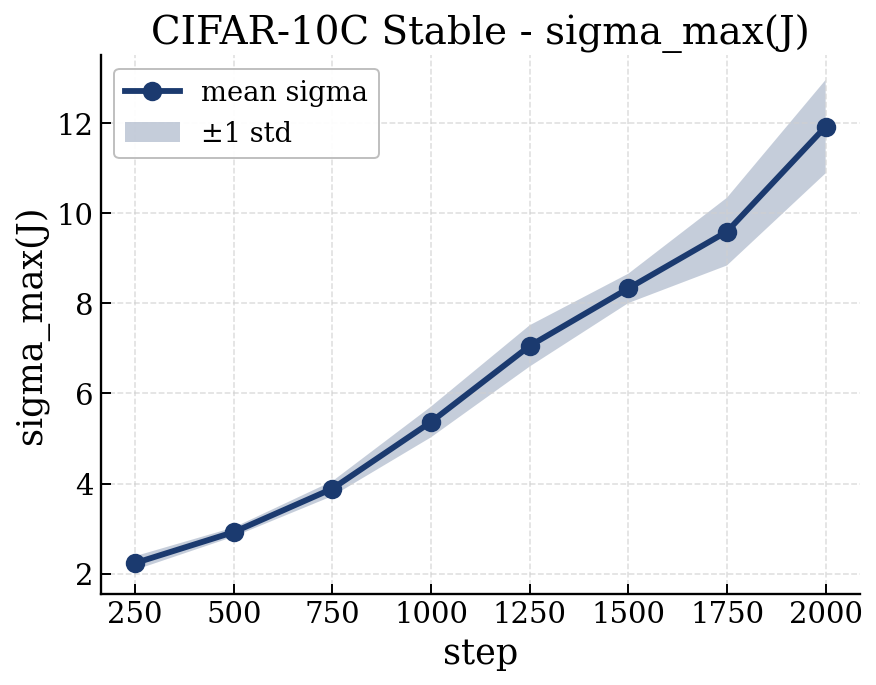

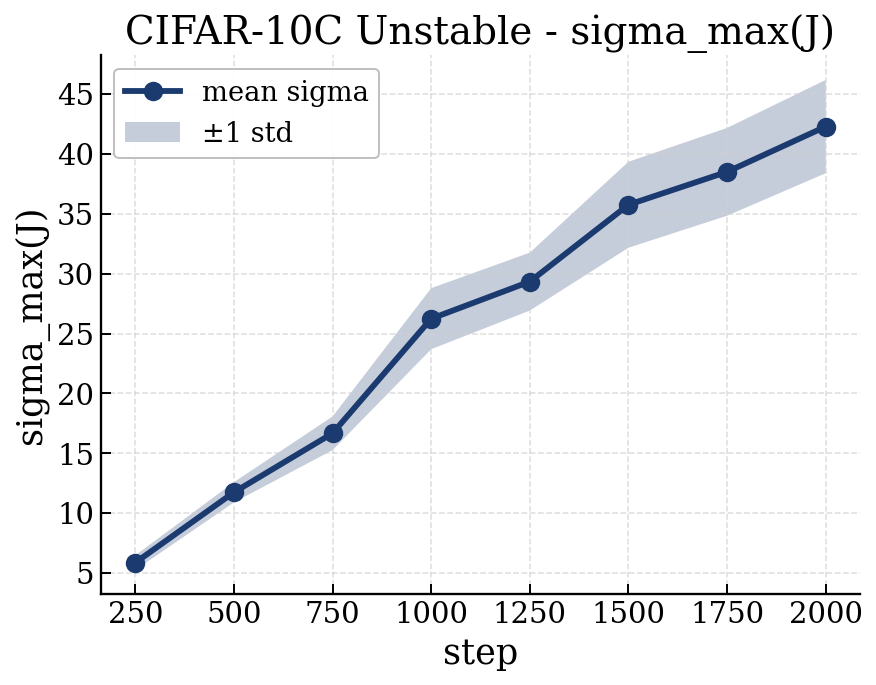

In [99]:
plot_sigma_band(cifar_demo3_stable, "CIFAR-10C Stable - sigma_max(J)")
plot_sigma_band(cifar_demo3_unst,   "CIFAR-10C Unstable - sigma_max(J)")

# Universal plotter (works for MNIST / CIFAR / CIFAR-10-C)

In [112]:
import numpy as np
import matplotlib.pyplot as plt

def _bandplot(logs, key_mean, key_std, label):
    steps = np.array(logs["step"])
    mean  = np.array(logs[key_mean])
    std   = np.array(logs[key_std])
    plt.plot(steps, mean, marker="o", label=label)
    plt.fill_between(steps, mean-std, mean+std, alpha=0.2)

def plot_logs_uq(stable_logs, unstable_logs, title):
    """
    Works for:
      - MNIST runs (UQ keys present)
      - CIFAR-10 runs (UQ keys present)
      - CIFAR-10-C Demo-3 runs (adds c10c_acc_mean/std)
    Assumes logs contain at least: step, test_acc.
    """

    # 1) Clean test accuracy
    plt.figure(figsize=[10,6])
    plt.plot(stable_logs["step"], stable_logs["test_acc"], marker="o", label="stable test acc")
    plt.plot(unstable_logs["step"], unstable_logs["test_acc"], marker="o", label="unstable test acc")
    plt.title(title + " - Clean Test Accuracy")
    plt.xlabel("Step"); plt.ylabel("Acc"); plt.legend(); plt.show()

    # 2) sigma_max(J) (either UQ or legacy)
    if "sigma_mean" in stable_logs and "sigma_std" in stable_logs:
        plt.figure()
        _bandplot(stable_logs, "sigma_mean", "sigma_std", "stable sigma_mean ± std")
        _bandplot(unstable_logs, "sigma_mean", "sigma_std", "unstable sigma_mean ± std")
        plt.title(title + " - sigma_max(J) with UQ")
        plt.xlabel("Step"); plt.ylabel("Sigma_max(J)"); plt.legend(); plt.show()
    elif "sigma" in stable_logs:
        plt.figure()
        plt.plot(stable_logs["step"], stable_logs["sigma"], marker="o", label="stable sigma")
        plt.plot(unstable_logs["step"], unstable_logs["sigma"], marker="o", label="unstable sigma")
        plt.title(title + " - sigma_max(J)")
        plt.xlabel("Step"); plt.ylabel("Sigma_max(J)"); plt.legend(); plt.show()

    # 3) resolvent proxy (either UQ or legacy)
    if "res_mean" in stable_logs and "res_std" in stable_logs:
        plt.figure()
        _bandplot(stable_logs, "res_mean", "res_std", "stable resolvent ± std")
        _bandplot(unstable_logs, "res_mean", "res_std", "unstable resolvent ± std")
        plt.title(title + " - Resolvent Proxy with UQ")
        plt.xlabel("Step"); plt.ylabel("Resolvent proxy"); plt.legend(); plt.show()
    elif "resolv" in stable_logs:
        plt.figure()
        plt.plot(stable_logs["step"], stable_logs["resolv"], marker="o", label="stable resolvent")
        plt.plot(unstable_logs["step"], unstable_logs["resolv"], marker="o", label="unstable resolvent")
        plt.title(title + " - Resolvent Proxy")
        plt.xlabel("Step"); plt.ylabel("Resolvent proxy"); plt.legend(); plt.show()

    # 4) Noisy accuracy under Gaussian input noise (UQ)
    if "noise_acc_mean" in stable_logs and "noise_acc_std" in stable_logs:
        plt.figure()
        _bandplot(stable_logs, "noise_acc_mean", "noise_acc_std", "stable noisy acc ± std")
        _bandplot(unstable_logs, "noise_acc_mean", "noise_acc_std", "unstable noisy acc ± std")
        plt.title(title + " - Accuracy Under Input Noise with UQ")
        plt.xlabel("Step"); plt.ylabel("Acc under noise"); plt.legend(); plt.show()

    # 5) Predictive entropy under noise (if logged)
    if "noise_ent" in stable_logs:
        plt.figure()
        plt.plot(stable_logs["step"], stable_logs["noise_ent"], marker="o", label="stable entropy")
        plt.plot(unstable_logs["step"], unstable_logs["noise_ent"], marker="o", label="unstable entropy")
        plt.title(title + " - Predictive Entropy Under Noise")
        plt.xlabel("Step"); plt.ylabel("Entropy"); plt.legend(); plt.show()

    # 6) CIFAR-10-C robustness (Demo-3 only)
    if "c10c_acc_mean" in stable_logs and "c10c_acc_std" in stable_logs:
        plt.figure()
        _bandplot(stable_logs, "c10c_acc_mean", "c10c_acc_std", "stable C10-C acc ± std")
        _bandplot(unstable_logs, "c10c_acc_mean", "c10c_acc_std", "unstable C10-C acc ± std")
        plt.title(title + " - CIFAR-10-C Robustness (severity fixed)")
        plt.xlabel("Step"); plt.ylabel("CIFAR-10-C acc"); plt.legend(); plt.show()

In [118]:
def plot_sigma_vs_metric(stable_logs, unstable_logs, x_key="sigma_mean", y_key="noise_acc_mean", title="sigma vs metric"):
    """
    Scatter plot: sigma_mean (or sigma) vs chosen robustness metric.
    Examples:
      - y_key="noise_acc_mean"  (MNIST/CIFAR noise robustness)
      - y_key="c10c_acc_mean"   (CIFAR-10-C robustness)
    """
    def get_xy(logs):
        x = logs[x_key] if x_key in logs else logs.get("sigma", None)
        y = logs.get(y_key, None)
        if x is None or y is None:
            return None, None
        return np.array(x, dtype=float), np.array(y, dtype=float)

    xs, ys = get_xy(stable_logs)
    xu, yu = get_xy(unstable_logs)

    if xs is None or xu is None:
        raise KeyError(f"Missing required keys. Need x_key={x_key} and y_key={y_key} (or sigma).")

    plt.figure(dpi=300)
    plt.scatter(xs, ys, s=80, label="stable")
    plt.scatter(xu, yu, s=80, label="unstable")
    plt.xlabel(x_key)
    plt.ylabel(y_key)
    plt.title(title)
    plt.legend()
    plt.show()

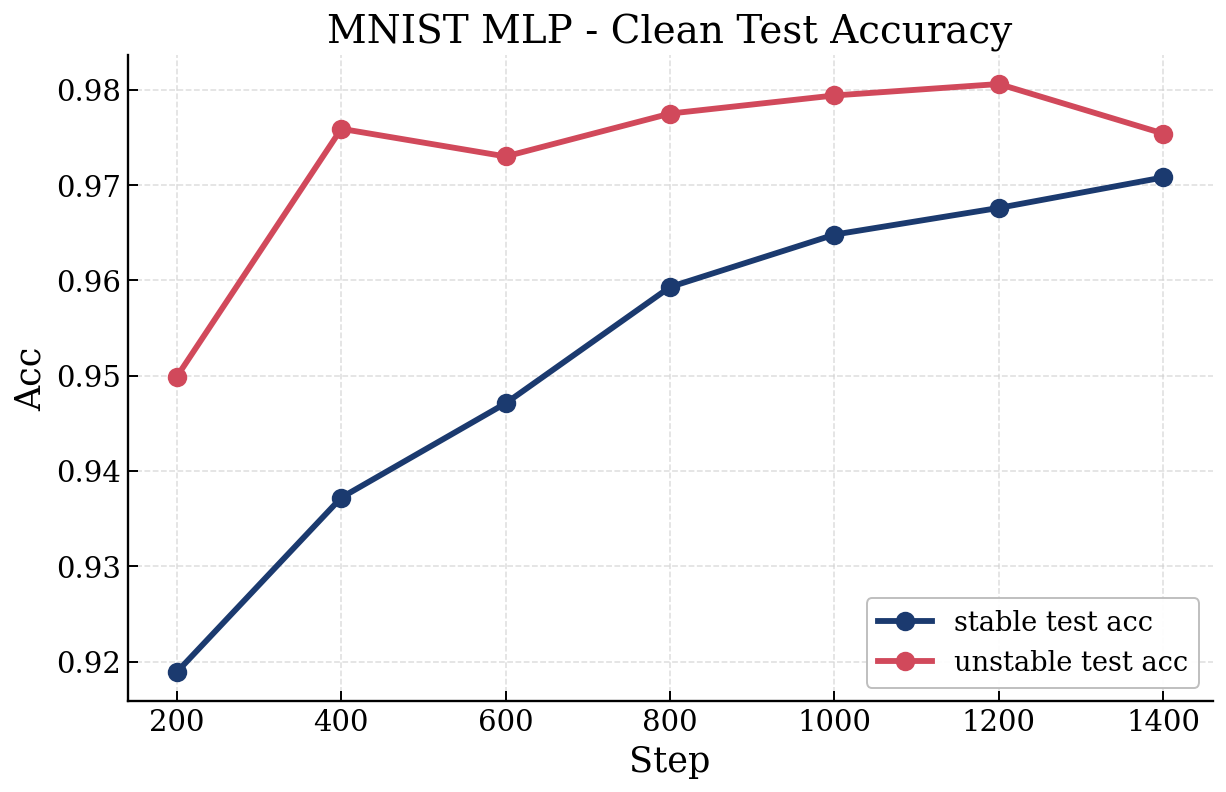

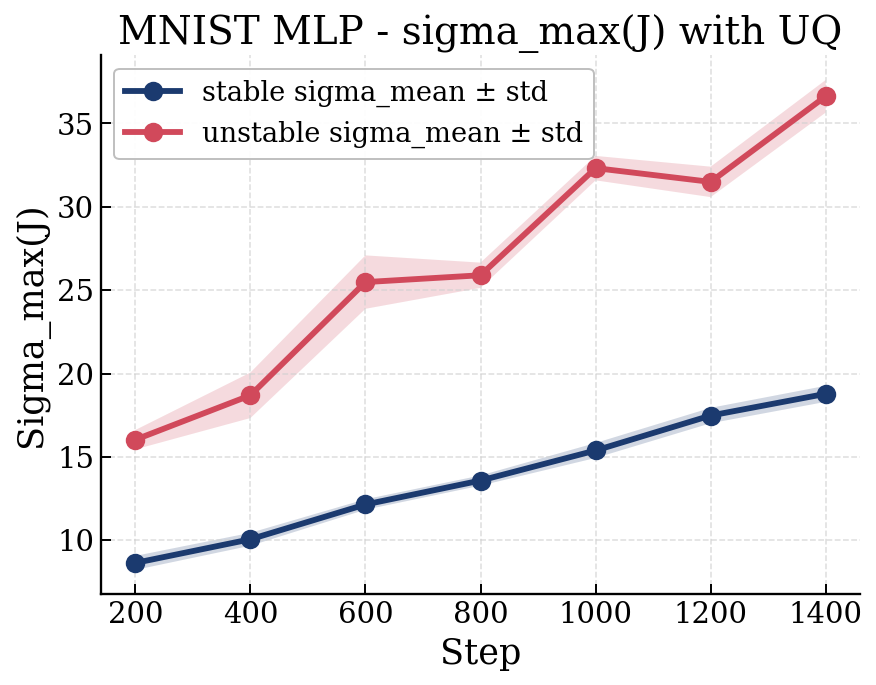

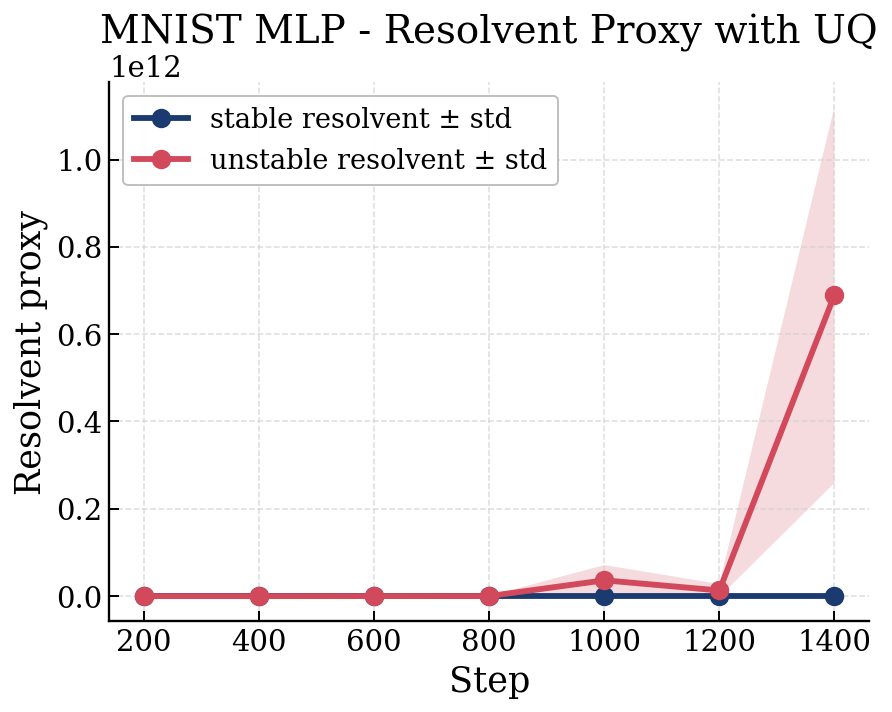

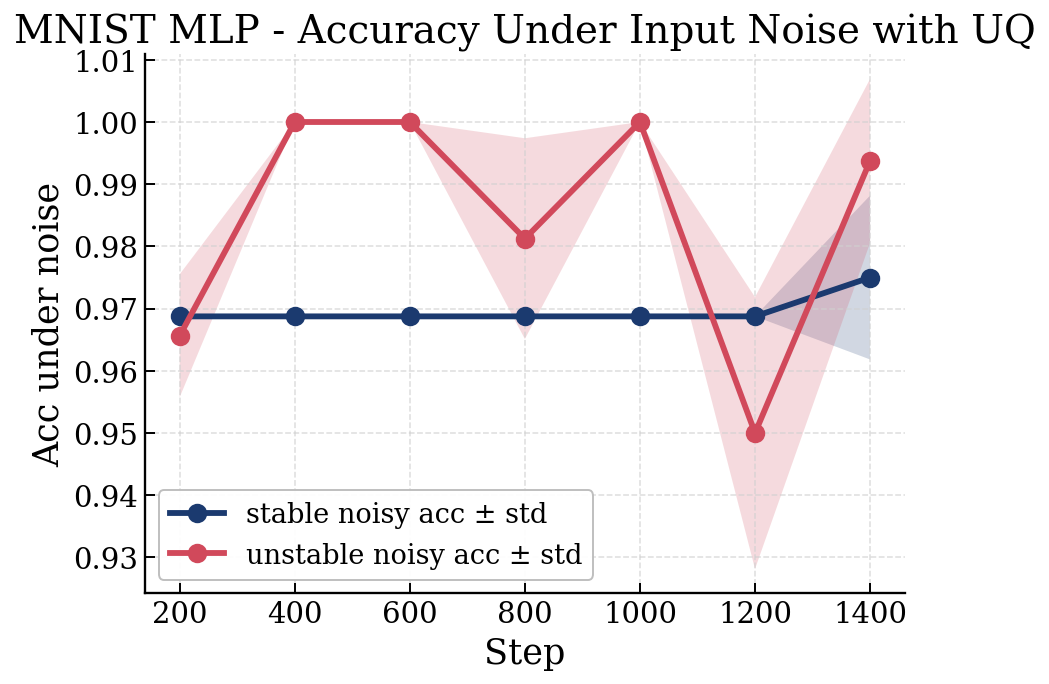

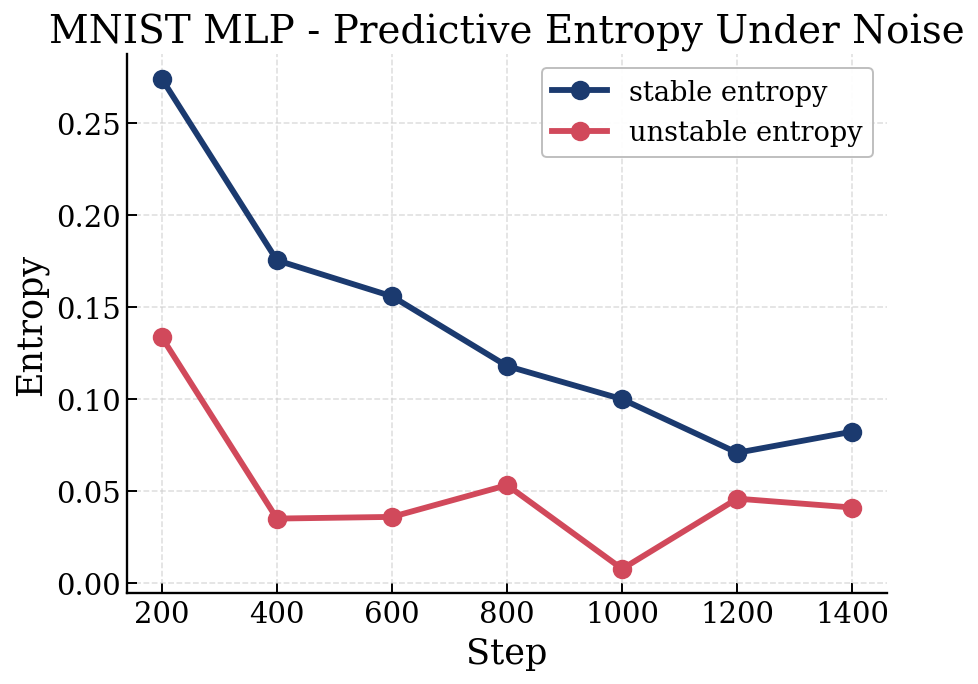

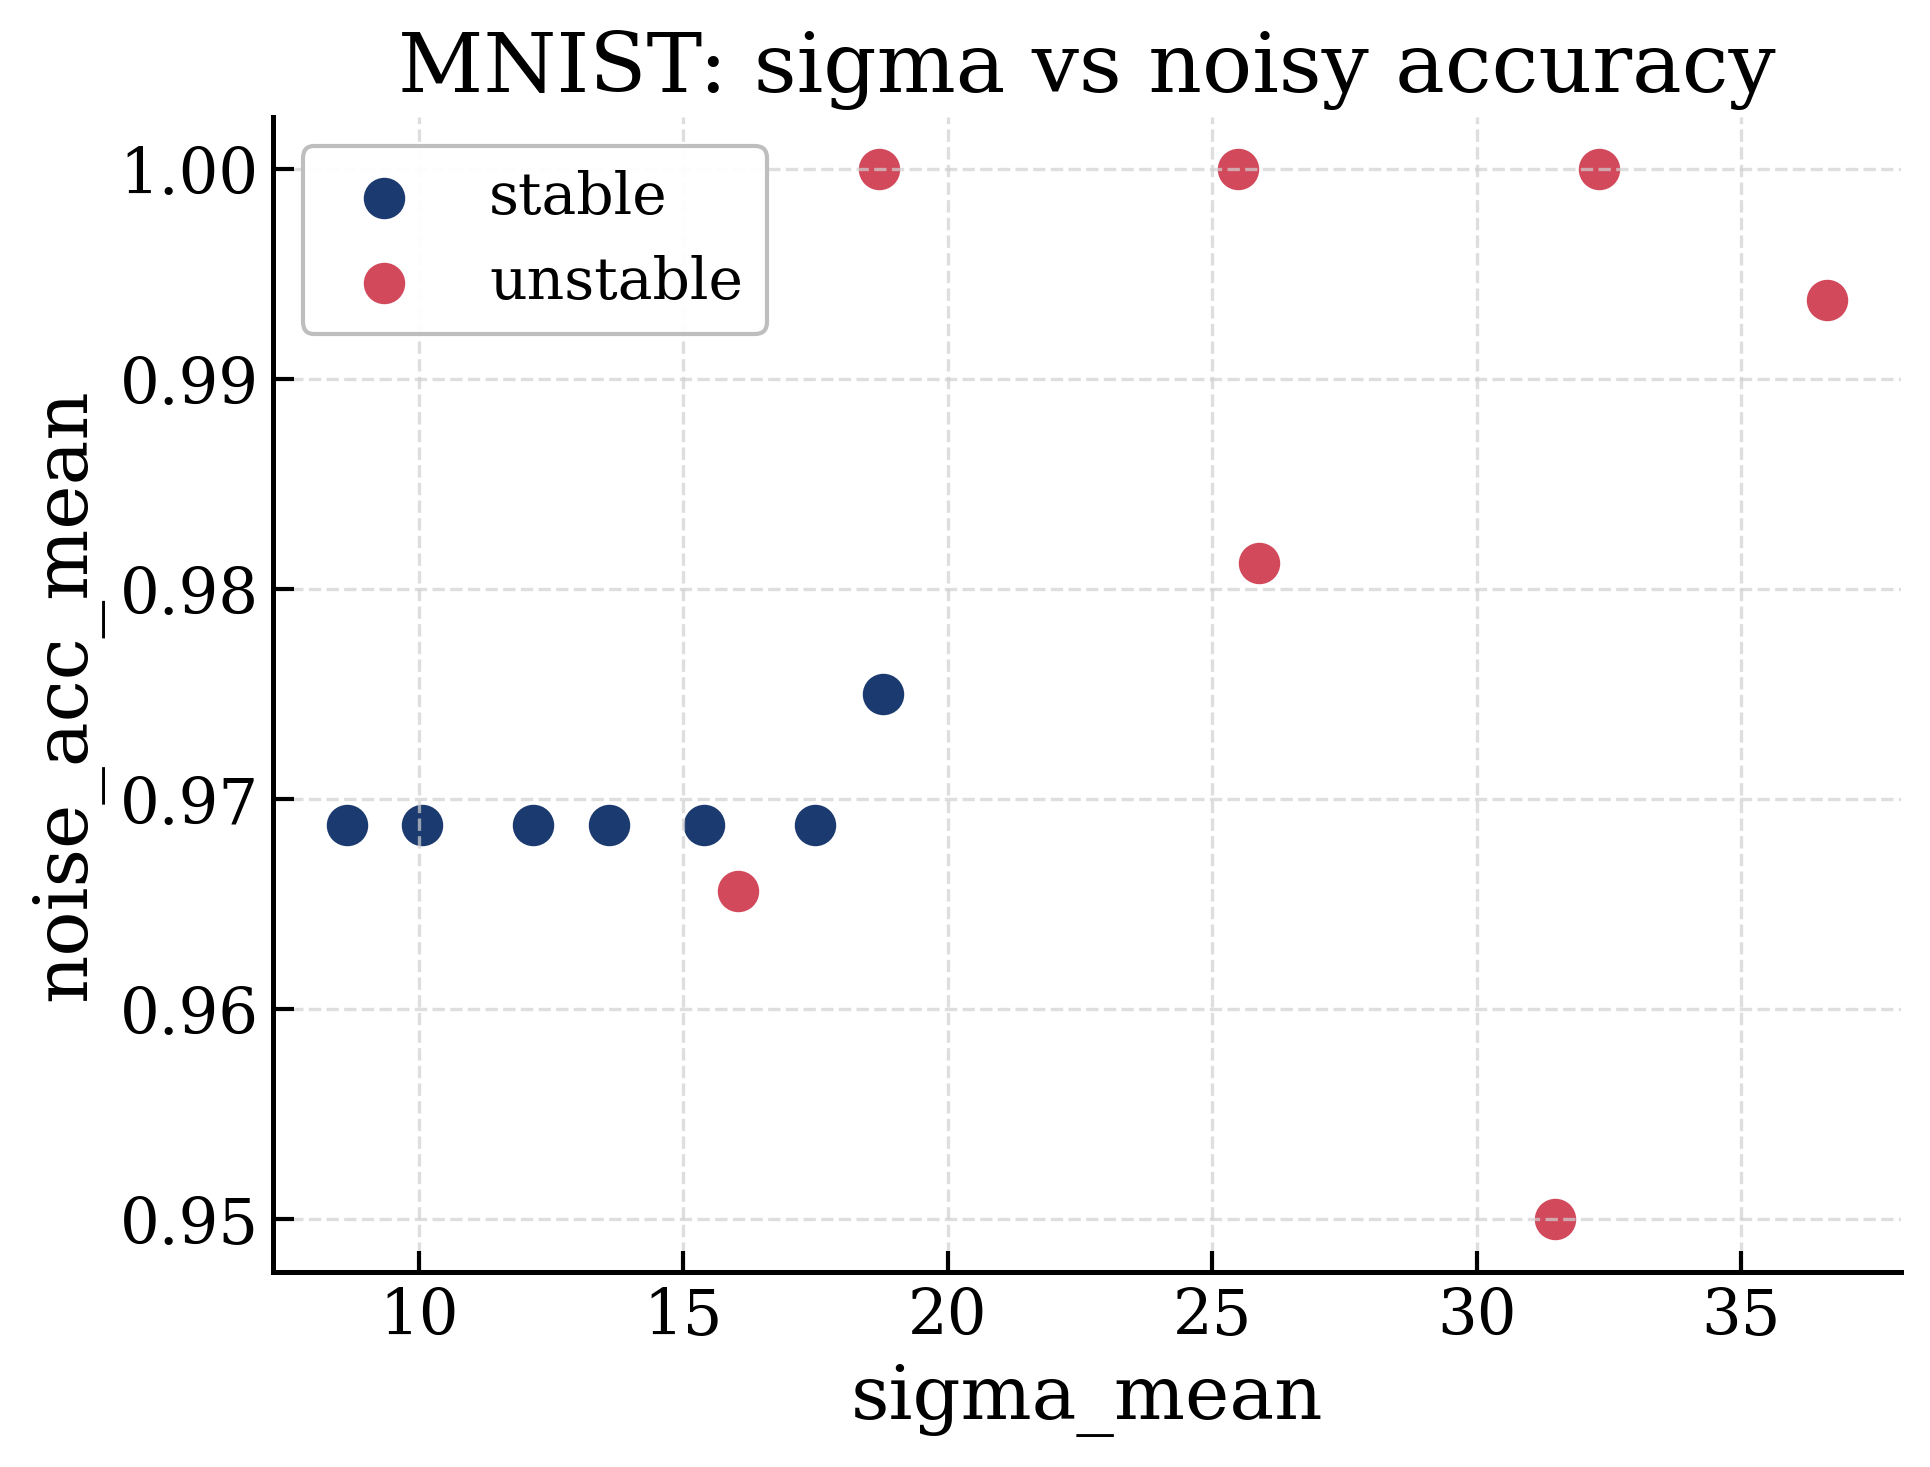

In [119]:
plot_logs_uq(mnist_stable, mnist_unst, "MNIST MLP")
plot_sigma_vs_metric(mnist_stable, mnist_unst, y_key="noise_acc_mean", title="MNIST: sigma vs noisy accuracy")

In [120]:
#plt.style.use('default')
#set_luxury_scientific_style()
#luxury_pub_style()
publication_luxury_style()

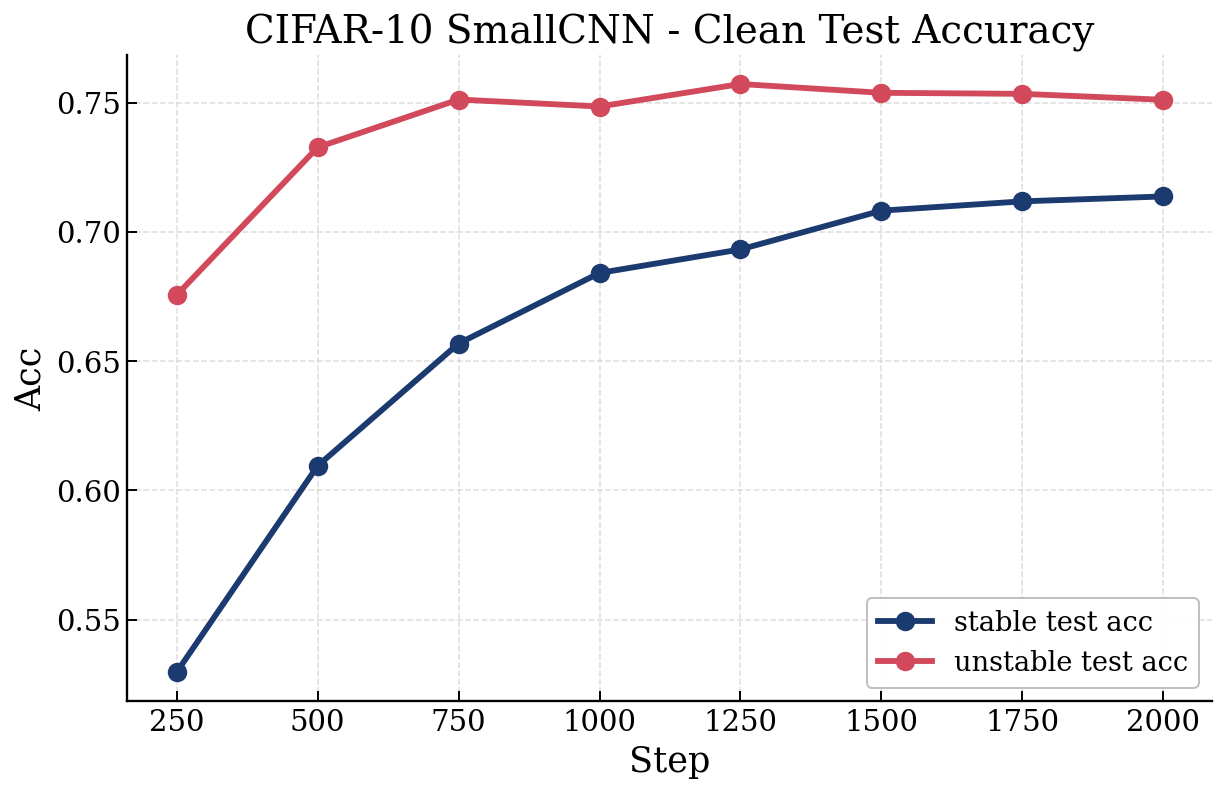

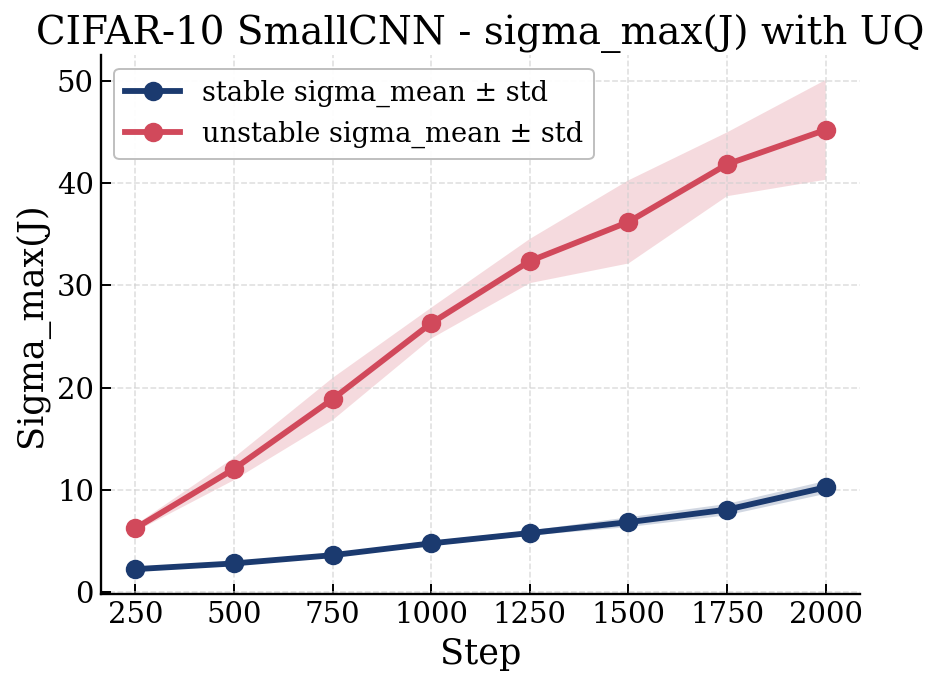

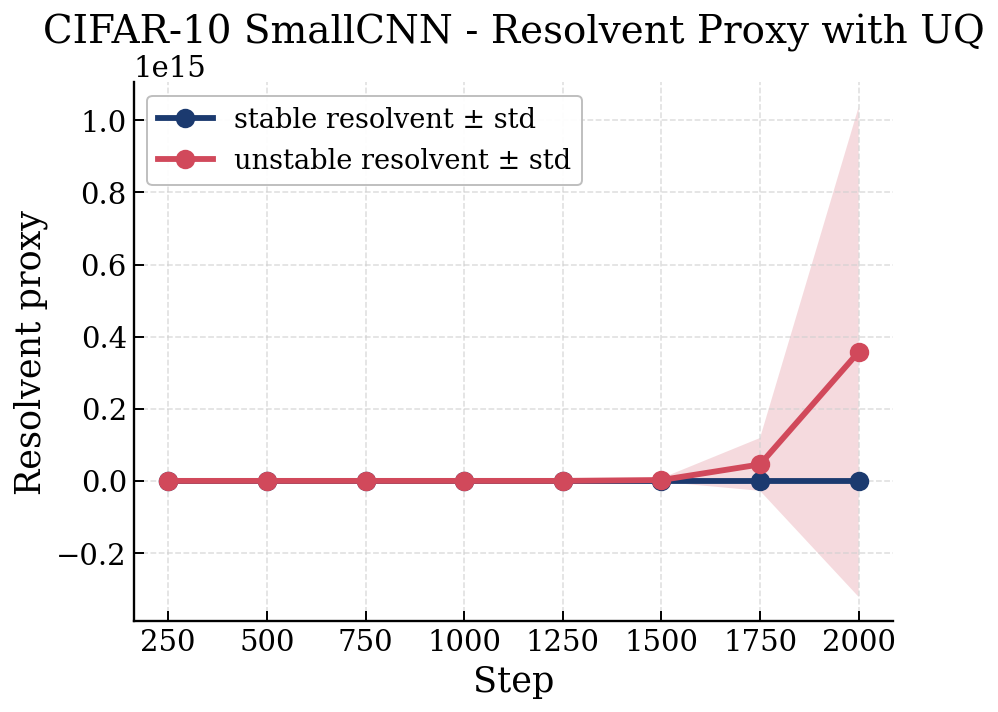

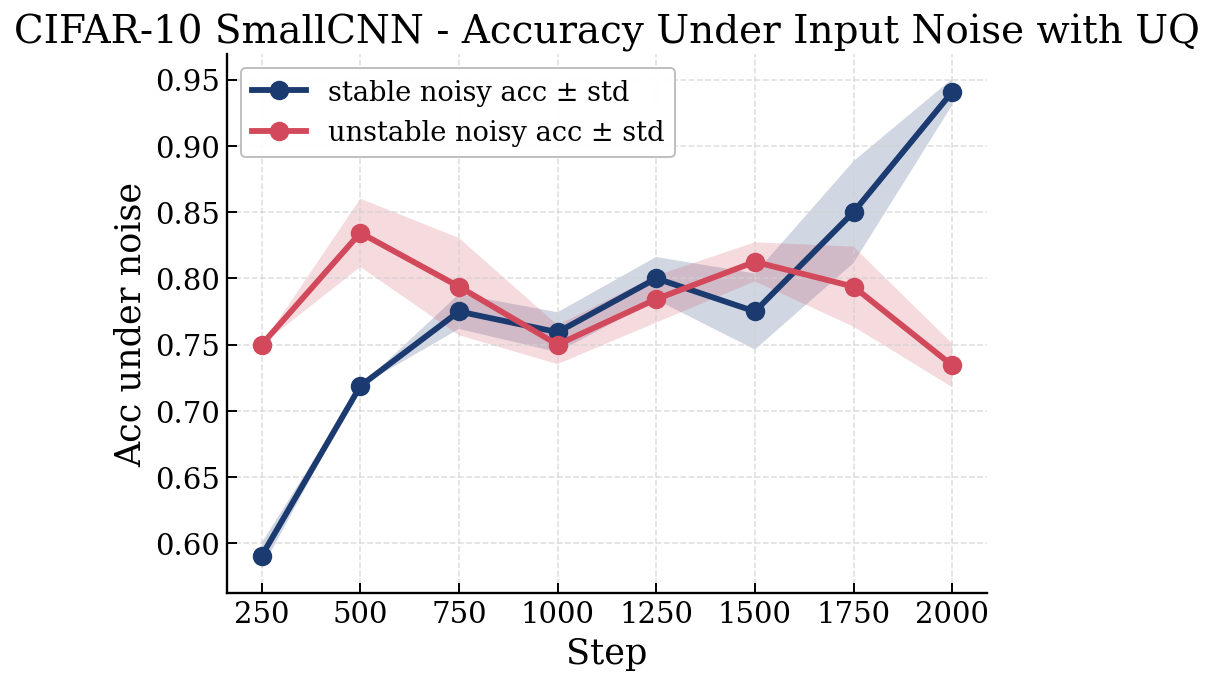

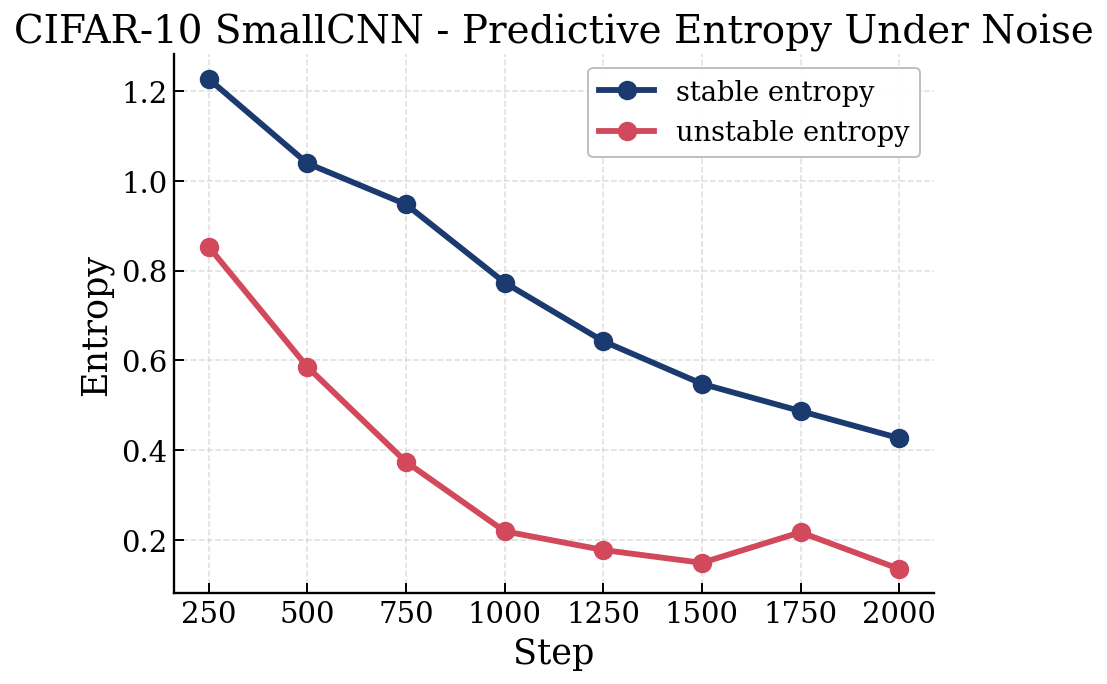

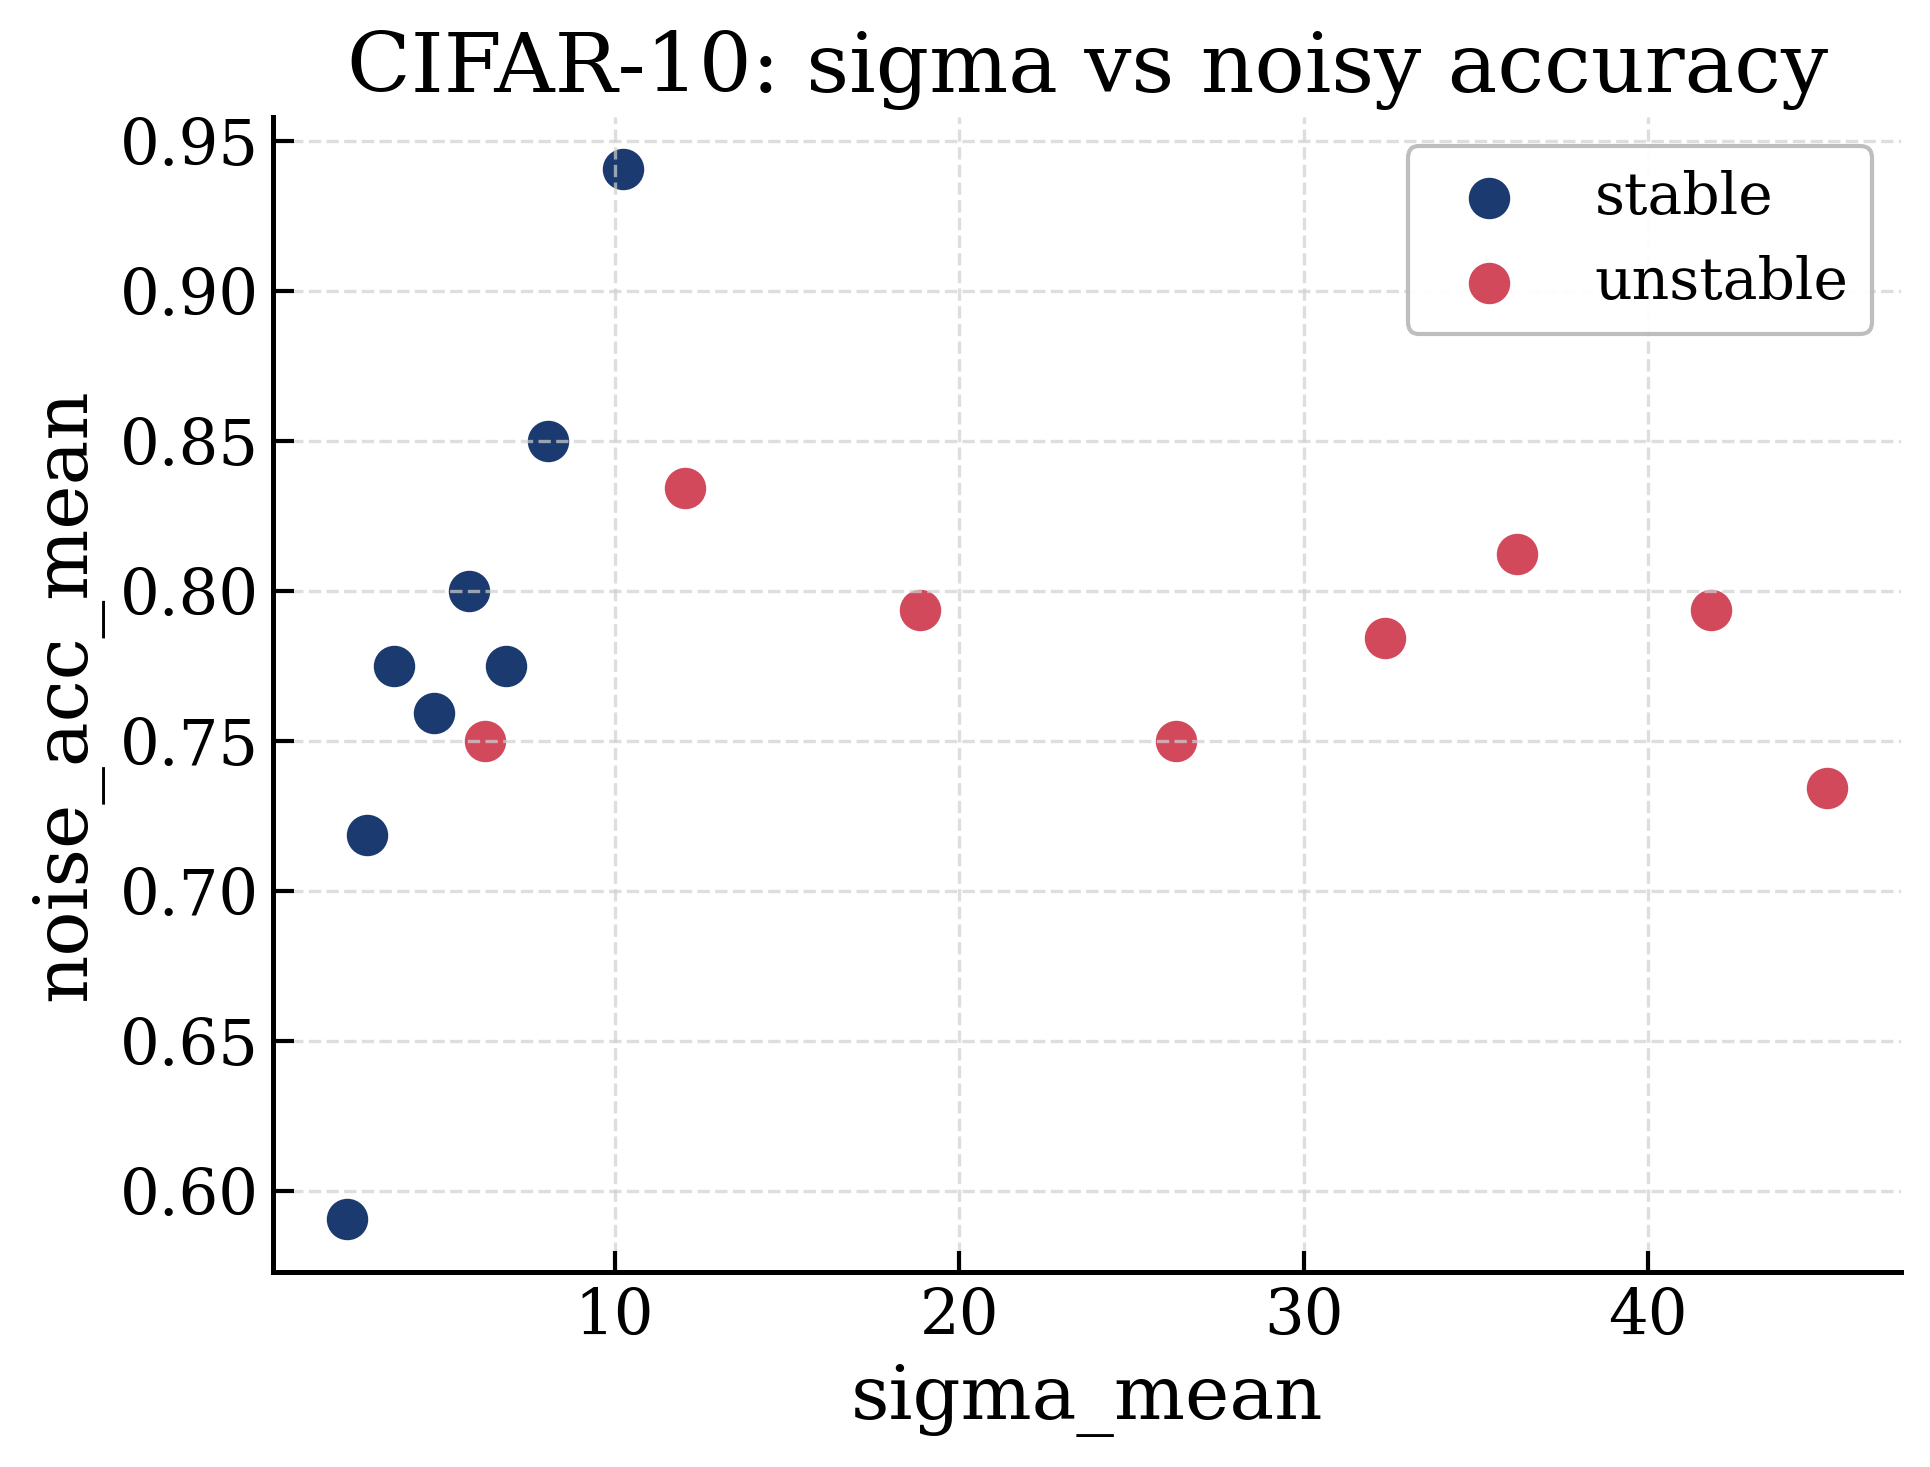

In [121]:
plot_logs_uq(cifar_stable, cifar_unst, "CIFAR-10 SmallCNN")
plot_sigma_vs_metric(cifar_stable, cifar_unst, y_key="noise_acc_mean", title="CIFAR-10: sigma vs noisy accuracy")

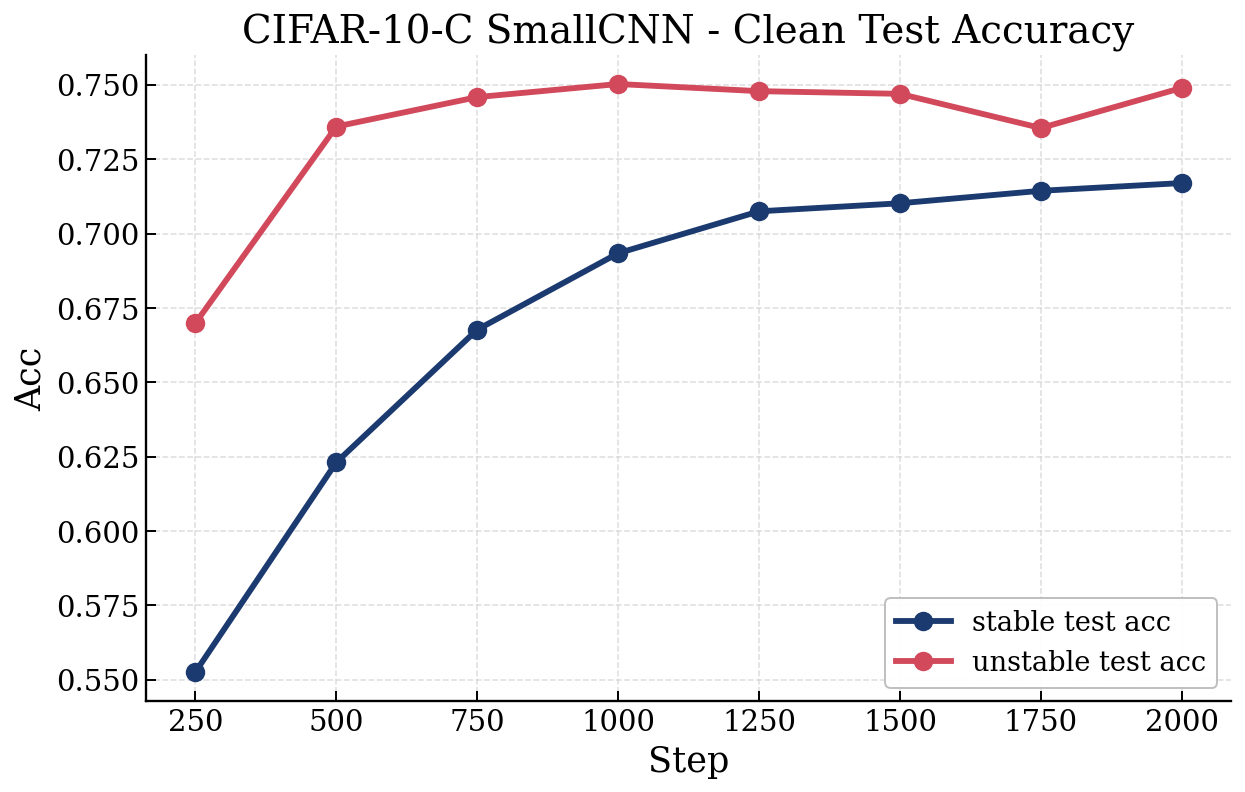

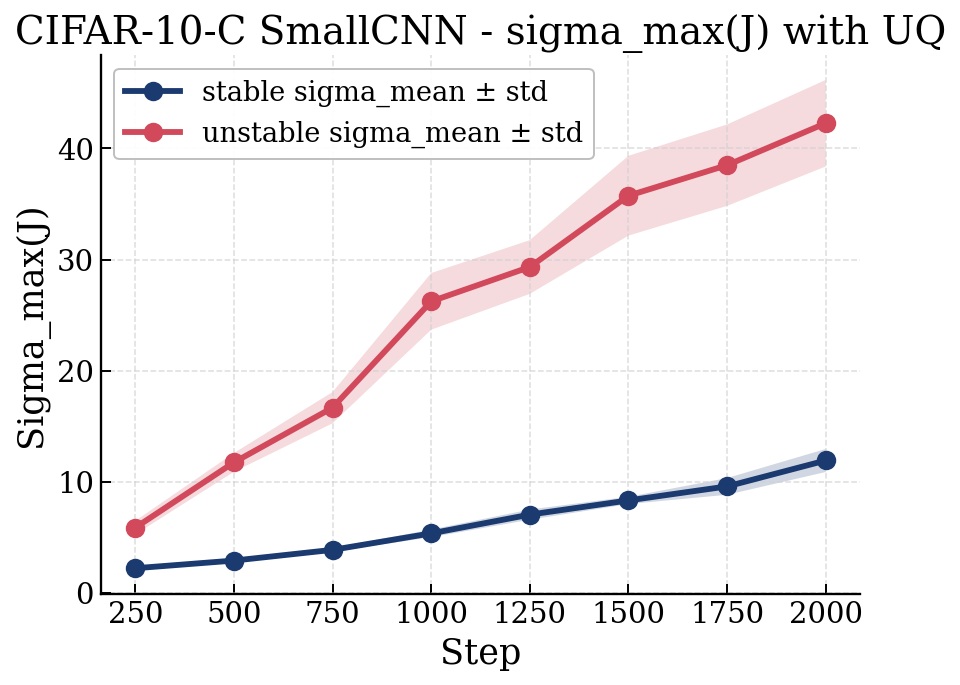

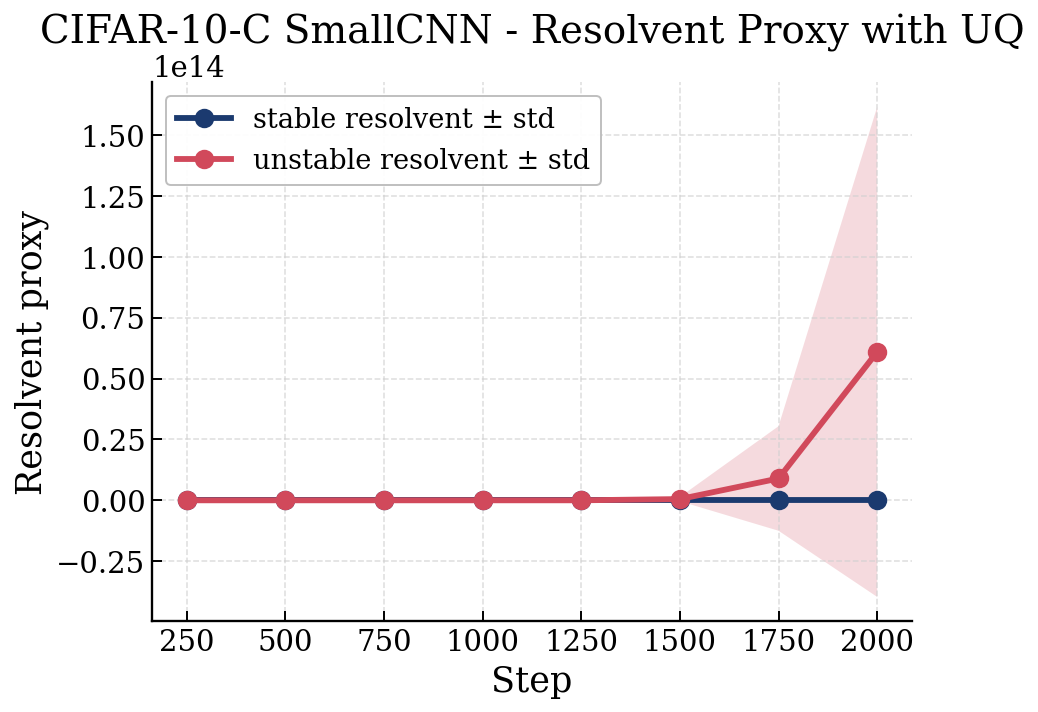

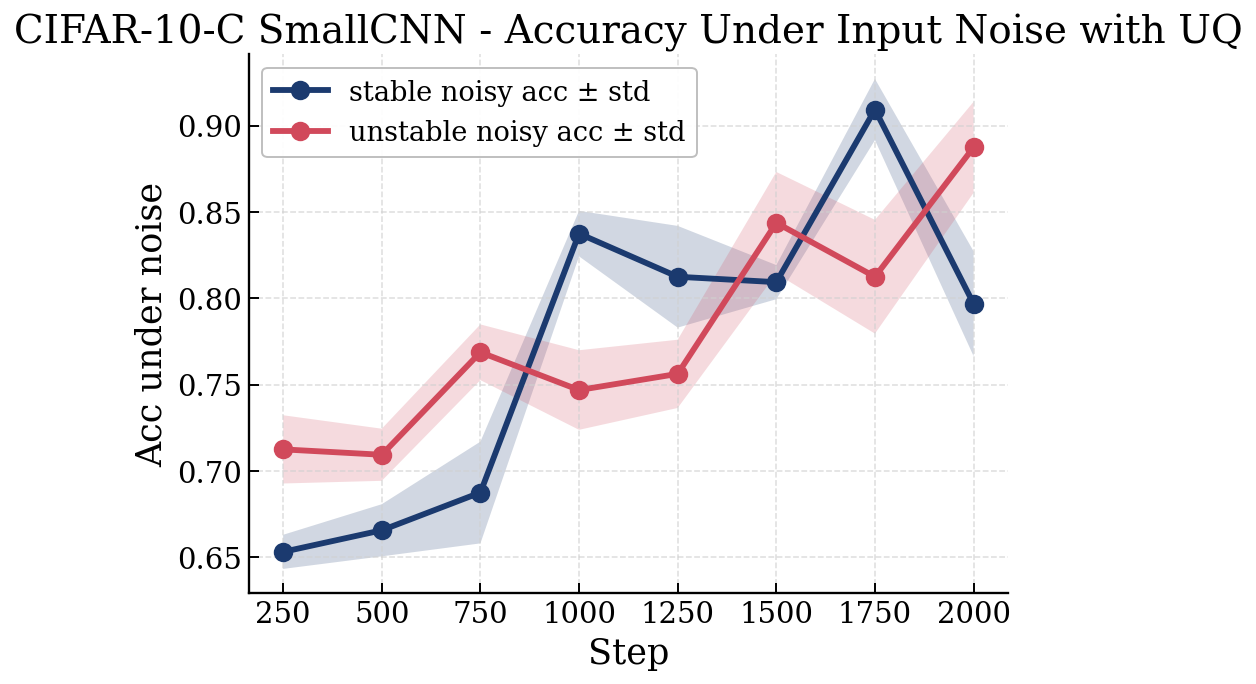

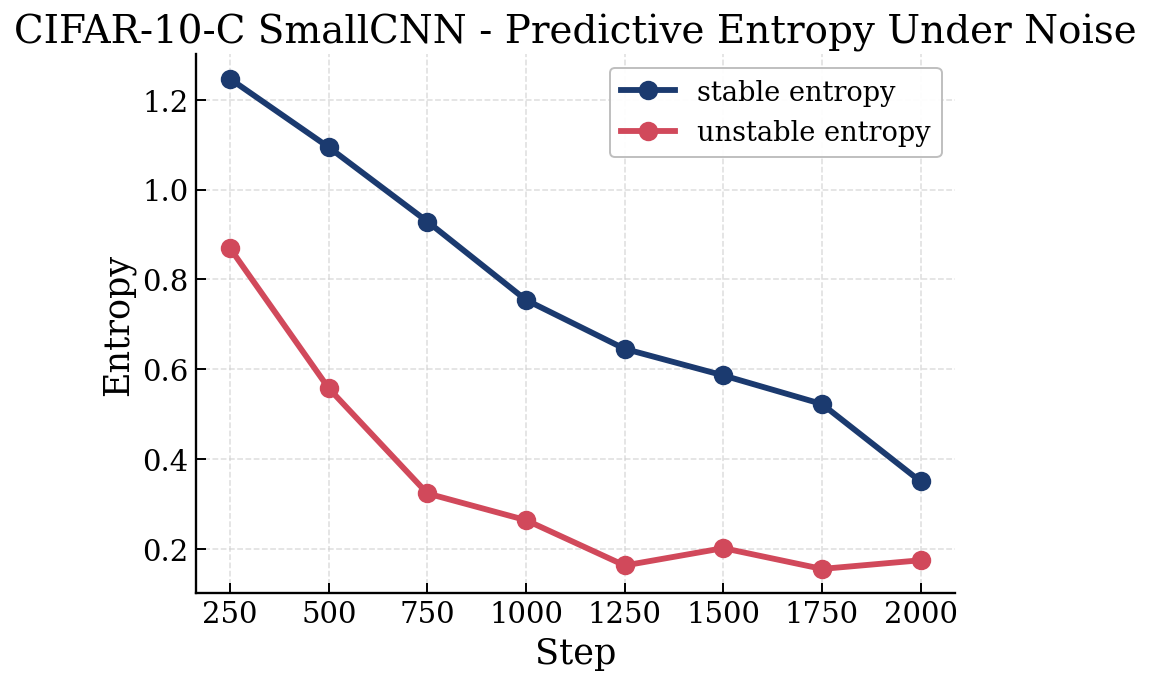

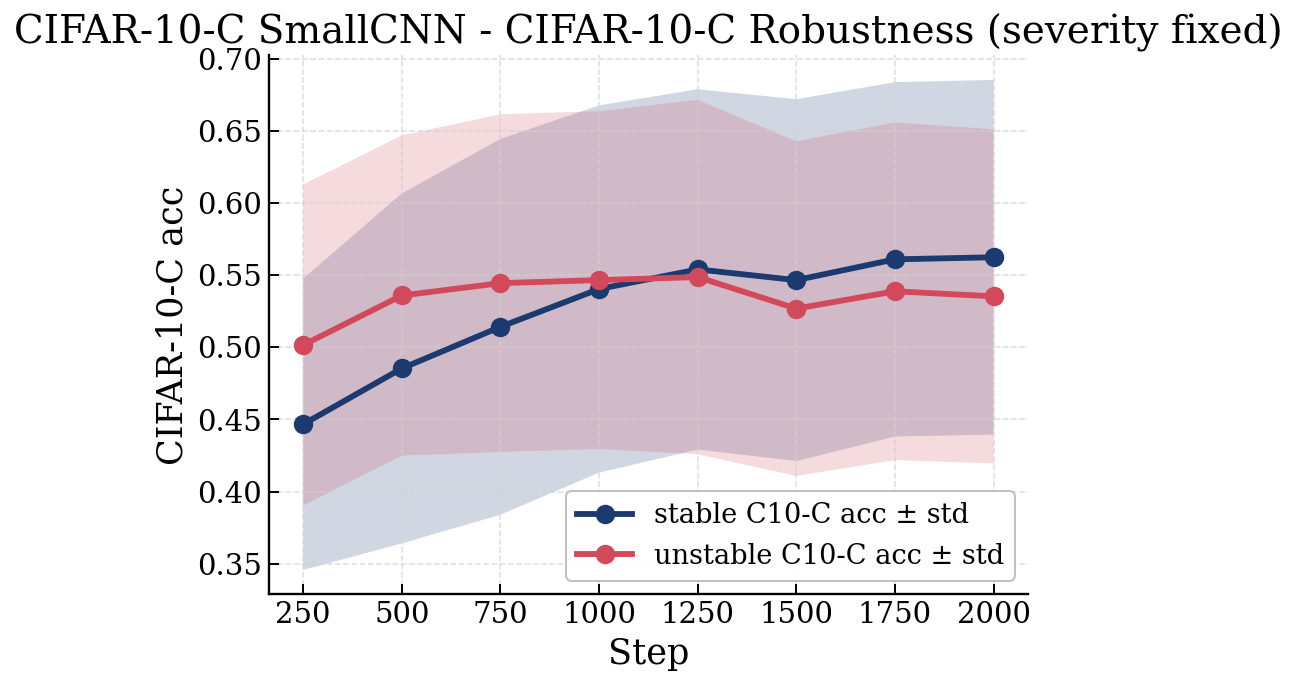

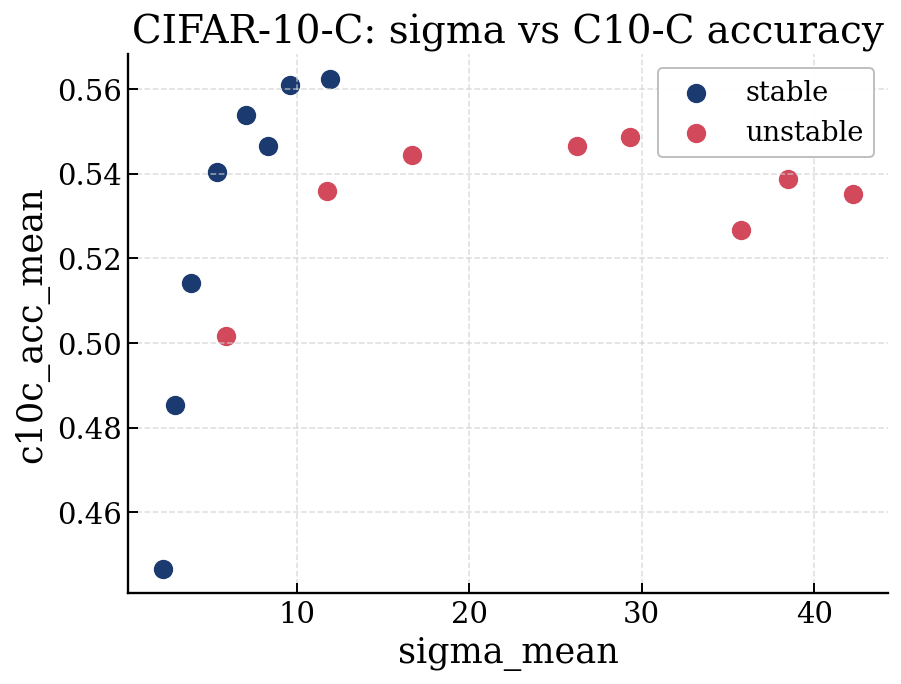

In [117]:
plot_logs_uq(cifar_demo3_stable, cifar_demo3_unst, "CIFAR-10-C SmallCNN")
plot_sigma_vs_metric(cifar_demo3_stable, cifar_demo3_unst, y_key="c10c_acc_mean", title="CIFAR-10-C: sigma vs C10-C accuracy")

## Clean severity sweep code

### Severity sweep function

In [52]:
import numpy as np

@torch.no_grad()
def eval_cifar10c_severity_sweep(
    model,
    c10c_root,
    device,
    transform,
    severities=(1,2,3,4,5),
    corruptions=None,
    batch_size=256,
):
    """
    Evaluate CIFAR-10-C robustness for severities 1..5.
    Returns dict: {"severity": [...], "mean": [...], "std": [...], "per_corruption": {...}}
      - mean/std are across corruption types at each severity.
      - per_corruption[corr] = list of accuracies across severities (optional but useful).
    """
    if corruptions is None:
        corruptions = CIFAR10C_CORRUPTIONS

    means, stds = [], []
    per_corr = {c: [] for c in corruptions}

    for sev in severities:
        accs = []
        for corr in corruptions:
            ds = CIFAR10CDataset(c10c_root, corr, severity=sev, transform=transform)
            dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
            a = eval_acc_on_loader(model, dl, device)
            accs.append(a)
            per_corr[corr].append(a)

        accs = np.array(accs, dtype=float)
        means.append(float(accs.mean()))
        stds.append(float(accs.std(ddof=1)))

    return {
        "severity": list(severities),
        "mean": means,
        "std": stds,
        "per_corruption": per_corr,  # useful for debugging/analysis
    }

### 2 Plot severity curves (stable vs unstable)

In [53]:
import matplotlib.pyplot as plt
import numpy as np

def plot_severity_sweep(res_stable, res_unst, title="CIFAR-10-C Severity Sweep"):
    sev_s = np.array(res_stable["severity"])
    m_s   = np.array(res_stable["mean"])
    sd_s  = np.array(res_stable["std"])

    sev_u = np.array(res_unst["severity"])
    m_u   = np.array(res_unst["mean"])
    sd_u  = np.array(res_unst["std"])

    plt.figure()
    plt.plot(sev_s, m_s, marker="o", label="stable (mean over corruptions)")
    plt.fill_between(sev_s, m_s - sd_s, m_s + sd_s, alpha=0.25)

    plt.plot(sev_u, m_u, marker="o", label="unstable (mean over corruptions)")
    plt.fill_between(sev_u, m_u - sd_u, m_u + sd_u, alpha=0.25)

    plt.xticks(sev_s)
    plt.xlabel("severity (1–5)")
    plt.ylabel("CIFAR-10-C accuracy")
    plt.title(title)
    plt.legend()
    plt.show()

### 3 Run the sweep at the end of training

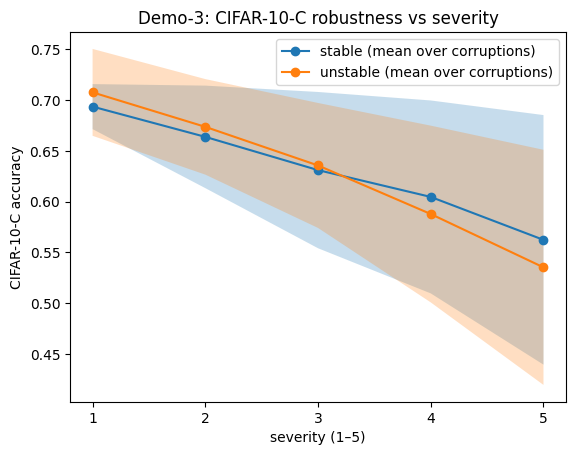

In [54]:
# choose corruptions: full list (15) for final figure
corruptions = CIFAR10C_CORRUPTIONS

stable_sweep = eval_cifar10c_severity_sweep(
    model=cifar_demo3_stable_model,
    c10c_root=C10C_ROOT,
    device=device,
    transform=apply_norm,
    severities=(1,2,3,4,5),
    corruptions=corruptions,
    batch_size=256,
)

unst_sweep = eval_cifar10c_severity_sweep(
    model=cifar_demo3_unst_model,
    c10c_root=C10C_ROOT,
    device=device,
    transform=apply_norm,
    severities=(1,2,3,4,5),
    corruptions=corruptions,
    batch_size=256,
)

plot_severity_sweep(stable_sweep, unst_sweep, title="Demo-3: CIFAR-10-C robustness vs severity")

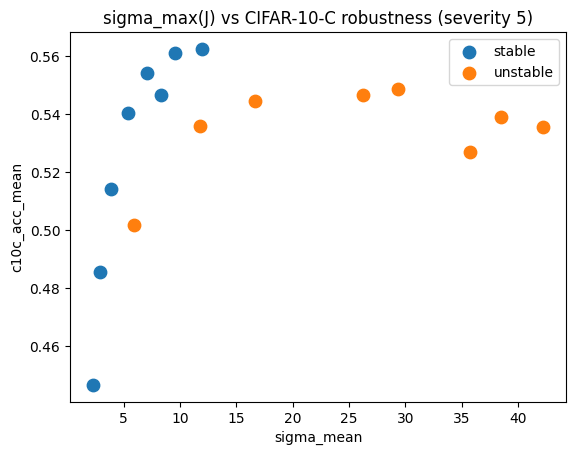

In [55]:
plot_sigma_vs_metric(
    cifar_demo3_stable,
    cifar_demo3_unst,
    y_key="c10c_acc_mean",
    title="sigma_max(J) vs CIFAR-10-C robustness (severity 5)"
)

# Fit Quadratic Model (Cleanly)

In [56]:
import numpy as np

# Combine stable + unstable data
sigma_all = np.array(
    cifar_demo3_stable["sigma_mean"] +
    cifar_demo3_unst["sigma_mean"]
)

c10c_all = np.array(
    cifar_demo3_stable["c10c_acc_mean"] +
    cifar_demo3_unst["c10c_acc_mean"]
)

print("N points:", len(sigma_all))

N points: 16


In [57]:
# Fit quadratic
coeffs = np.polyfit(sigma_all, c10c_all, deg=2)
a, b, c = coeffs

print("Quadratic coefficients:")
print(f"a = {a:.6f}")
print(f"b = {b:.6f}")
print(f"c = {c:.6f}")

Quadratic coefficients:
a = -0.000146
b = 0.006975
c = 0.481614


In [58]:
# Predictions
c10c_pred = np.polyval(coeffs, sigma_all)

# R^2
ss_res = np.sum((c10c_all - c10c_pred)**2)
ss_tot = np.sum((c10c_all - np.mean(c10c_all))**2)
r2 = 1 - ss_res/ss_tot

print("R^2 =", r2)

R^2 = 0.4763799175864436


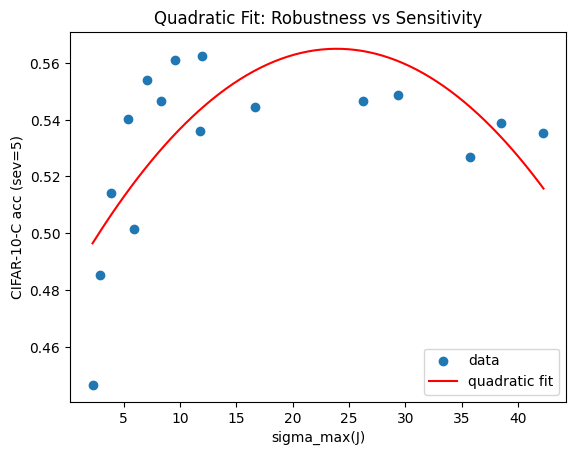

In [59]:
import matplotlib.pyplot as plt

# smooth curve
sigma_grid = np.linspace(min(sigma_all), max(sigma_all), 200)
c10c_curve = np.polyval(coeffs, sigma_grid)

plt.figure()
plt.scatter(sigma_all, c10c_all, label="data")
plt.plot(sigma_grid, c10c_curve, color="red", label="quadratic fit")
plt.xlabel("sigma_max(J)")
plt.ylabel("CIFAR-10-C acc (sev=5)")
plt.legend()
plt.title("Quadratic Fit: Robustness vs Sensitivity")
plt.show()

## Clean modified training loop with Jacobian regularization

## JVP helper

In [60]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jvp

def jacobian_jvp_penalty(model, x, n_vecs=1):
    """
    Returns mean ||J(x)v||^2 over n_vecs random unit vectors v.
    x: input batch, requires_grad not necessary for jvp
    """
    model.eval()  # jvp doesn't require train mode; but keep consistent if you want
    B = x.shape[0]
    pen = 0.0

    # define function mapping x -> logits
    def f(inp):
        return model(inp)

    for _ in range(n_vecs):
        v = torch.randn_like(x)
        v = v / (v.flatten(1).norm(dim=1, keepdim=True).view(B, *([1]*(x.ndim-1))) + 1e-12)

        # jvp returns (f(x), Jv)
        _, Jv = jvp(f, (x,), (v,), create_graph=True)
        pen = pen + (Jv.pow(2).sum(dim=1).mean())  # sum over classes, mean over batch

    return pen / n_vecs

In [61]:
import torch

def fd_jacobian_penalty(model, x, eps=1e-3, n_vecs=1):
    """
    Finite-difference directional Jacobian penalty:
      E_v ||(f(x+eps*v)-f(x))/eps||^2
    - No higher-order derivatives.
    - Works with maxpool / non-smooth ops.
    """
    B = x.shape[0]
    pen = 0.0

    for _ in range(n_vecs):
        v = torch.randn_like(x)
        v = v / (v.flatten(1).norm(dim=1, keepdim=True).view(B, *([1]*(x.ndim-1))) + 1e-12)

        fx  = model(x)
        fxp = model(x + eps * v)

        Jv_fd = (fxp - fx) / eps
        pen = pen + (Jv_fd.pow(2).sum(dim=1).mean())  # sum over classes, mean over batch

    return pen / n_vecs

### Clean training loop: CIFAR-10 with optional Jacobian regularization + Demo-3 logging

In [62]:
from tqdm.auto import tqdm
import numpy as np

def train_run_cifar_demo3_with_jacreg(
    tag: str,
    c10c_root: str,
    model_ctor,
    train_loader,
    test_loader,
    device,
    # optimizer
    lr=2e-3,
    weight_decay=0.0,
    steps=2000,
    diag_every=250,
    # Jacobian regularization
    lambda_jac=0.0,        # set >0 to enable
    jac_n_vecs=1,          # 1 is usually enough
    jac_batch_cap=64,      # compute penalty on a smaller batch for speed
    # operator-UQ diagnostics (your existing functions)
    f_fn=None,
    uq_nbatches=5,
    uq_nprobes=3,
    sigma_iters=10,
    resolv_K=15,
    resolv_alpha=100.0,
    # noise-UQ
    noise_std=0.05,
    noise_nsamples_ent=20,
    noise_nsamples_acc=10,
    diag_batch_cap=32,
    # CIFAR-10-C
    c10c_severity=5,
    c10c_corruptions=None,
    c10c_batch_size=256,
):
    model = model_ctor().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    logs = {
        "step": [], "loss": [], "ce_loss": [], "jac_pen": [],
        "train_acc": [], "test_acc": [], "grad_norm": [],
        "sigma_mean": [], "sigma_std": [],
        "res_mean": [], "res_std": [],
        "noise_ent": [],
        "noise_acc_mean": [], "noise_acc_std": [],
        "c10c_acc_mean": [], "c10c_acc_std": [],
    }

    it = iter(train_loader)

    for step in tqdm(range(1, steps + 1), desc=f"Demo-3+JacReg {tag}"):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y = next(it)

        x, y = x.to(device), y.to(device)

        model.train()
        logits = model(x)
        ce_loss = F.cross_entropy(logits, y)

        jac_pen = torch.tensor(0.0, device=device)
        if lambda_jac > 0.0:
            # compute on a smaller subset for speed
            xj = x[:jac_batch_cap].detach()  # detach to avoid weird graph growth
            xj.requires_grad_(True)          # allow jvp graph
            #jac_pen = jacobian_jvp_penalty(model, xj, n_vecs=jac_n_vecs)
            #jac_pen = fd_jacobian_penalty(model, xj, n_vecs=jac_n_vecs)
            jac_pen = fd_jacobian_penalty(model, xj, eps=1e-3, n_vecs=1)

        loss = ce_loss + lambda_jac * jac_pen

        opt.zero_grad(set_to_none=True)
        loss.backward()

        grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters() if p.grad is not None)).item()
        opt.step()

        if step % diag_every == 0:
            train_acc = (logits.argmax(-1) == y).float().mean().item()
            test_acc = eval_acc_on_loader(model, test_loader, device)

            # diagnostics batch
            xb, yb = next(iter(test_loader))
            xb, yb = xb.to(device)[:diag_batch_cap], yb.to(device)[:diag_batch_cap]

            # --- operator-UQ diagnostics (requires your existing diag_with_uncertainty) ---
            diag = diag_with_uncertainty(
                model, test_loader, f_fn,
                nbatches=uq_nbatches, nprobes=uq_nprobes,
                alpha=resolv_alpha,
                sigma_iters=sigma_iters, resolv_K=resolv_K,
                batch_cap=diag_batch_cap
            )

            # --- noise-UQ ---
            ent = predictive_entropy_under_noise(model, xb, noise_std=noise_std, nsamples=noise_nsamples_ent)
            nacc_mu, nacc_sd = accuracy_under_noise(model, xb, yb, noise_std=noise_std, nsamples=noise_nsamples_acc)

            # --- CIFAR-10-C robustness ---
            c10c_mu, c10c_sd = eval_cifar10c(
                model,
                c10c_root=c10c_root,
                device=device,
                transform=apply_norm,
                severity=c10c_severity,
                corruptions=c10c_corruptions,
                batch_size=c10c_batch_size,
            )

            logs["step"].append(step)
            logs["loss"].append(float(loss.item()))
            logs["ce_loss"].append(float(ce_loss.item()))
            logs["jac_pen"].append(float(jac_pen.item()))
            logs["train_acc"].append(float(train_acc))
            logs["test_acc"].append(float(test_acc))
            logs["grad_norm"].append(float(grad_norm))

            logs["sigma_mean"].append(diag["sigma_mean"])
            logs["sigma_std"].append(diag["sigma_std"])
            logs["res_mean"].append(diag["res_mean"])
            logs["res_std"].append(diag["res_std"])

            logs["noise_ent"].append(float(ent))
            logs["noise_acc_mean"].append(float(nacc_mu))
            logs["noise_acc_std"].append(float(nacc_sd))

            logs["c10c_acc_mean"].append(float(c10c_mu))
            logs["c10c_acc_std"].append(float(c10c_sd))

            print(
                f"[{tag}] step={step} "
                f"loss={loss.item():.3f} (ce={ce_loss.item():.3f}, jac={jac_pen.item():.3e}, lam={lambda_jac:g}) "
                f"train={train_acc:.3f} test={test_acc:.3f} "
                f"sigma={diag['sigma_mean']:.2f}±{diag['sigma_std']:.2f} "
                f"c10c(sev{c10c_severity})={c10c_mu:.3f}±{c10c_sd:.3f}"
            )

    return model, logs

In [63]:
# (1) stable
m_stable, log_stable = train_run_cifar_demo3_with_jacreg(
    tag="stable",
    c10c_root=C10C_ROOT,
    model_ctor=SmallCNN,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    device=device,
    lr=3e-4,
    weight_decay=1e-2,
    steps=2000,
    diag_every=250,
    lambda_jac=0.0,
    f_fn=f_logits_cnn,
    c10c_severity=5,
)

# (2) unstable
m_unst, log_unst = train_run_cifar_demo3_with_jacreg(
    tag="unstable",
    c10c_root=C10C_ROOT,
    model_ctor=SmallCNN,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    device=device,
    lr=2e-3,
    weight_decay=0.0,
    steps=2000,
    diag_every=250,
    lambda_jac=0.0,
    f_fn=f_logits_cnn,
    c10c_severity=5,
)

# (3) unstable + jacobian regularization
m_unst_jac, log_unst_jac = train_run_cifar_demo3_with_jacreg(
    tag="unstable+jacreg",
    c10c_root=C10C_ROOT,
    model_ctor=SmallCNN,
    train_loader=train_loader_c,
    test_loader=test_loader_c,
    device=device,
    lr=2e-3,
    weight_decay=0.0,
    steps=2000,
    diag_every=250,
    lambda_jac=1e-4,
    jac_n_vecs=1,
    f_fn=f_logits_cnn,
    c10c_severity=5,
)

Demo-3+JacReg stable:   0%|          | 0/2000 [00:00<?, ?it/s]

RuntimeError: max_pool2d with `return_indices=False` is not infinitely differentiable. If you want to calculate higher order derivatives, e.g. second order, set `return_indices=True`.

In [64]:
import inspect, re

def find_create_graph_in(fn):
    src = inspect.getsource(fn)
    if "create_graph=True" in src:
        print(f"Found in: {fn.__name__}")
        for i, line in enumerate(src.splitlines(), 1):
            if "create_graph=True" in line:
                print(f"  L{i}: {line}")

# Add your functions here
for f in [diag_with_uncertainty, sigma_max_jacobian, resolvent_proxy_JTJ,
          predictive_entropy_under_noise, accuracy_under_noise]:
    try:
        find_create_graph_in(f)
    except Exception:
        pass

In [65]:
import torch
import torch.nn.functional as F

def fd_jacobian_penalty(model, x, eps=1e-3, n_vecs=1):
    """
    Finite-difference directional sensitivity penalty:
      E_v ||(f(x+eps*v)-f(x))/eps||^2
    No jvp, no autograd.grad(inputs=x), no higher-order derivatives.
    """
    B = x.shape[0]
    pen = 0.0
    for _ in range(n_vecs):
        v = torch.randn_like(x)
        v = v / (v.flatten(1).norm(dim=1, keepdim=True).view(B, *([1]*(x.ndim-1))) + 1e-12)

        fx  = model(x)
        fxp = model(x + eps * v)
        Jv_fd = (fxp - fx) / eps
        pen = pen + (Jv_fd.pow(2).sum(dim=1).mean())  # sum over classes, mean over batch
    return pen / n_vecs

In [66]:
def train_step_fd_jacreg(model, opt, x, y, lambda_jac=1e-4, jac_batch_cap=64, eps=1e-3, n_vecs=1):
    model.train()
    x, y = x.to(next(model.parameters()).device), y.to(next(model.parameters()).device)

    logits = model(x)
    ce_loss = F.cross_entropy(logits, y)

    # IMPORTANT: detach so x has no graph; FD needs none anyway
    jac_pen = torch.tensor(0.0, device=logits.device)
    if lambda_jac > 0:
        xj = x[:jac_batch_cap].detach()
        jac_pen = fd_jacobian_penalty(model, xj, eps=eps, n_vecs=n_vecs)

    loss = ce_loss + lambda_jac * jac_pen

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    acc = (logits.argmax(-1) == y).float().mean().item()
    return float(loss.item()), float(ce_loss.item()), float(jac_pen.item()), float(acc)

In [67]:
model = SmallCNN().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.0)  # "unstable" base

In [68]:
from tqdm.auto import tqdm

lambda_jac = 1e-4      # turn this to 0.0 to disable
jac_batch_cap = 64
eps = 1e-3
n_vecs = 1

it = iter(train_loader_c)
for step in tqdm(range(1, 501), desc="Sanity train (500 steps)"):
    try:
        x, y = next(it)
    except StopIteration:
        it = iter(train_loader_c)
        x, y = next(it)

    loss, ce, jac, acc = train_step_fd_jacreg(
        model, opt, x, y,
        lambda_jac=lambda_jac,
        jac_batch_cap=jac_batch_cap,
        eps=eps,
        n_vecs=n_vecs
    )

    if step % 100 == 0:
        print(f"step={step} loss={loss:.3f} ce={ce:.3f} jac={jac:.3e} acc={acc:.3f}")

Sanity train (500 steps):   0%|          | 0/500 [00:00<?, ?it/s]

step=100 loss=1.280 ce=1.280 jac=2.611e-03 acc=0.523
step=200 loss=0.902 ce=0.902 jac=1.071e-02 acc=0.695
step=300 loss=0.944 ce=0.944 jac=2.788e-02 acc=0.680
step=400 loss=0.642 ce=0.642 jac=3.787e-02 acc=0.777
step=500 loss=0.631 ce=0.631 jac=5.473e-02 acc=0.766


In [69]:
import numpy as np

def train_cifar_fd_jacreg(
    tag,
    model,
    opt,
    train_loader,
    test_loader,
    c10c_root,
    device,
    steps=2000,
    diag_every=250,
    lambda_jac=1e-4,
    jac_batch_cap=64,
    eps=1e-3,
    n_vecs=1,
    c10c_severity=5,
):
    logs = {
        "step": [], "loss": [], "ce_loss": [], "jac_pen": [], "train_acc": [],
        "test_acc": [], "c10c_acc_mean": [], "c10c_acc_std": []
    }

    it = iter(train_loader)
    for step in tqdm(range(1, steps+1), desc=f"{tag}"):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader)
            x, y = next(it)

        loss, ce, jac, acc = train_step_fd_jacreg(
            model, opt, x, y,
            lambda_jac=lambda_jac,
            jac_batch_cap=jac_batch_cap,
            eps=eps,
            n_vecs=n_vecs
        )

        if step % diag_every == 0:
            test_acc = eval_acc_on_loader(model, test_loader, device)

            c10c_mu, c10c_sd = eval_cifar10c(
                model,
                c10c_root=c10c_root,
                device=device,
                transform=apply_norm,
                severity=c10c_severity,
                corruptions=CIFAR10C_CORRUPTIONS,
                batch_size=256
            )

            logs["step"].append(step)
            logs["loss"].append(loss)
            logs["ce_loss"].append(ce)
            logs["jac_pen"].append(jac)
            logs["train_acc"].append(acc)
            logs["test_acc"].append(test_acc)
            logs["c10c_acc_mean"].append(c10c_mu)
            logs["c10c_acc_std"].append(c10c_sd)

            print(
                f"[{tag}] step={step} "
                f"loss={loss:.3f} (ce={ce:.3f}, jac={jac:.2e}, lam={lambda_jac:g}) "
                f"train={acc:.3f} test={test_acc:.3f} "
                f"c10c(sev{c10c_severity})={c10c_mu:.3f}±{c10c_sd:.3f}"
            )
    return logs

In [70]:
stable_model = SmallCNN().to(device)
stable_opt = torch.optim.AdamW(stable_model.parameters(), lr=3e-4, weight_decay=1e-2)
stable_logs = train_cifar_fd_jacreg(
    "stable", stable_model, stable_opt,
    train_loader_c, test_loader_c,
    C10C_ROOT, device,
    lambda_jac=0.0,  # baseline
    c10c_severity=5
)

stable:   0%|          | 0/2000 [00:00<?, ?it/s]

[stable] step=250 loss=1.212 (ce=1.212, jac=0.00e+00, lam=0) train=0.598 test=0.541 c10c(sev5)=0.448±0.100
[stable] step=500 loss=1.016 (ce=1.016, jac=0.00e+00, lam=0) train=0.648 test=0.610 c10c(sev5)=0.502±0.115
[stable] step=750 loss=0.901 (ce=0.901, jac=0.00e+00, lam=0) train=0.703 test=0.659 c10c(sev5)=0.520±0.128
[stable] step=1000 loss=0.707 (ce=0.707, jac=0.00e+00, lam=0) train=0.781 test=0.685 c10c(sev5)=0.548±0.122
[stable] step=1250 loss=0.578 (ce=0.578, jac=0.00e+00, lam=0) train=0.793 test=0.702 c10c(sev5)=0.552±0.125
[stable] step=1500 loss=0.397 (ce=0.397, jac=0.00e+00, lam=0) train=0.875 test=0.709 c10c(sev5)=0.558±0.127
[stable] step=1750 loss=0.342 (ce=0.342, jac=0.00e+00, lam=0) train=0.883 test=0.714 c10c(sev5)=0.560±0.127
[stable] step=2000 loss=0.147 (ce=0.147, jac=0.00e+00, lam=0) train=0.961 test=0.718 c10c(sev5)=0.571±0.126


In [71]:
unst_model = SmallCNN().to(device)
unst_opt = torch.optim.AdamW(unst_model.parameters(), lr=2e-3, weight_decay=0.0)
unst_logs = train_cifar_fd_jacreg(
    "unstable", unst_model, unst_opt,
    train_loader_c, test_loader_c,
    C10C_ROOT, device,
    lambda_jac=0.0,
    c10c_severity=5
)

unstable:   0%|          | 0/2000 [00:00<?, ?it/s]

[unstable] step=250 loss=0.936 (ce=0.936, jac=0.00e+00, lam=0) train=0.660 test=0.683 c10c(sev5)=0.499±0.109
[unstable] step=500 loss=0.607 (ce=0.607, jac=0.00e+00, lam=0) train=0.797 test=0.736 c10c(sev5)=0.524±0.113
[unstable] step=750 loss=0.366 (ce=0.366, jac=0.00e+00, lam=0) train=0.883 test=0.745 c10c(sev5)=0.527±0.116
[unstable] step=1000 loss=0.094 (ce=0.094, jac=0.00e+00, lam=0) train=0.973 test=0.745 c10c(sev5)=0.534±0.113
[unstable] step=1250 loss=0.035 (ce=0.035, jac=0.00e+00, lam=0) train=0.996 test=0.739 c10c(sev5)=0.521±0.119
[unstable] step=1500 loss=0.027 (ce=0.027, jac=0.00e+00, lam=0) train=0.984 test=0.749 c10c(sev5)=0.539±0.112
[unstable] step=1750 loss=0.025 (ce=0.025, jac=0.00e+00, lam=0) train=0.996 test=0.752 c10c(sev5)=0.530±0.114
[unstable] step=2000 loss=0.045 (ce=0.045, jac=0.00e+00, lam=0) train=0.980 test=0.750 c10c(sev5)=0.525±0.121


In [72]:
unst_jac_model = SmallCNN().to(device)
unst_jac_opt = torch.optim.AdamW(unst_jac_model.parameters(), lr=2e-3, weight_decay=0.0)
unst_jac_logs = train_cifar_fd_jacreg(
    "unstable+fdjac", unst_jac_model, unst_jac_opt,
    train_loader_c, test_loader_c,
    C10C_ROOT, device,
    lambda_jac=1e-4,   # start here
    jac_batch_cap=64,
    eps=1e-3,
    n_vecs=1,
    c10c_severity=5
)

unstable+fdjac:   0%|          | 0/2000 [00:00<?, ?it/s]

[unstable+fdjac] step=250 loss=0.793 (ce=0.793, jac=3.00e-02, lam=0.0001) train=0.699 test=0.674 c10c(sev5)=0.497±0.111
[unstable+fdjac] step=500 loss=0.622 (ce=0.622, jac=6.02e-02, lam=0.0001) train=0.801 test=0.735 c10c(sev5)=0.517±0.119
[unstable+fdjac] step=750 loss=0.415 (ce=0.415, jac=1.91e-01, lam=0.0001) train=0.852 test=0.749 c10c(sev5)=0.519±0.120
[unstable+fdjac] step=1000 loss=0.082 (ce=0.082, jac=4.48e-01, lam=0.0001) train=0.961 test=0.752 c10c(sev5)=0.521±0.116
[unstable+fdjac] step=1250 loss=0.068 (ce=0.068, jac=6.62e-01, lam=0.0001) train=0.973 test=0.748 c10c(sev5)=0.527±0.115
[unstable+fdjac] step=1500 loss=0.055 (ce=0.055, jac=8.40e-01, lam=0.0001) train=0.973 test=0.756 c10c(sev5)=0.531±0.118
[unstable+fdjac] step=1750 loss=0.037 (ce=0.037, jac=1.04e+00, lam=0.0001) train=0.984 test=0.749 c10c(sev5)=0.525±0.116
[unstable+fdjac] step=2000 loss=0.070 (ce=0.069, jac=1.29e+00, lam=0.0001) train=0.977 test=0.743 c10c(sev5)=0.530±0.106


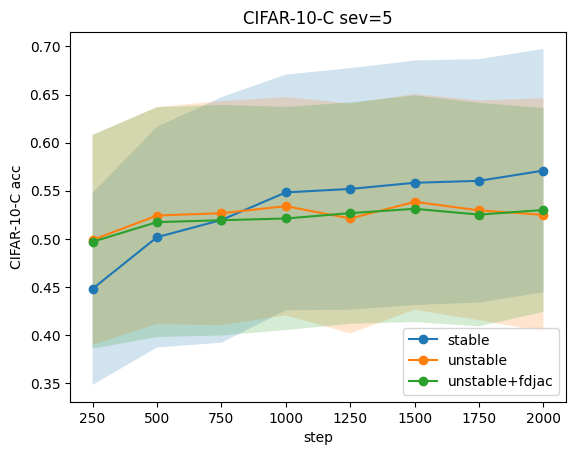

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def plot_c10c_three(logA, logB, logC, labels=("stable","unstable","unstable+fdjac"), title="CIFAR-10-C sev=5"):
    plt.figure()
    for logs, lab in zip([logA, logB, logC], labels):
        steps = np.array(logs["step"])
        mean  = np.array(logs["c10c_acc_mean"])
        std   = np.array(logs["c10c_acc_std"])
        plt.plot(steps, mean, marker="o", label=lab)
        plt.fill_between(steps, mean-std, mean+std, alpha=0.2)
    plt.xlabel("step"); plt.ylabel("CIFAR-10-C acc")
    plt.title(title); plt.legend(); plt.show()

plot_c10c_three(stable_logs, unst_logs, unst_jac_logs)

# Final Experiment: Early-warning prediction across many runs (the “monitoring” result)

In [74]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.GELU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.GELU(),
            #nn.MaxPool2d(2),  # 16x16
            nn.AvgPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GELU(),
            #nn.MaxPool2d(2),  # 8x8
            nn.AvgPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*8*8, 256), nn.GELU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

def f_logits_cnn(model, x):
    return model(x)  # [B,10]

In [75]:
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def run_one_trial_monitoring(
    seed,
    lr,
    weight_decay,
    steps_final=1000,
    early_step=500,
    jacreg=False,
    lambda_jac=0.0,
    eps=1e-3,
    device="mps",
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SmallCNN().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    it = iter(train_loader_c)

    early_sigma = None
    early_test_acc = None

    for step in range(1, steps_final + 1):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(train_loader_c)
            x, y = next(it)

        x, y = x.to(device), y.to(device)

        model.train()
        logits = model(x)
        ce = F.cross_entropy(logits, y)

        # optional FD-JacReg (keep off for monitoring study unless you want a second panel)
        if jacreg and lambda_jac > 0:
            xj = x[:64].detach()
            jac_pen = fd_jacobian_penalty(model, xj, eps=eps, n_vecs=1)
            loss = ce + lambda_jac * jac_pen
        else:
            loss = ce

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step == early_step:
            # compute early metrics
            early_test_acc = eval_acc_on_loader(model, test_loader_c, device)

            diag = diag_with_uncertainty(
                model, test_loader_c, f_logits_cnn,
                nbatches=3, nprobes=2,
                alpha=100.0,
                sigma_iters=8, resolv_K=10,
                batch_cap=32
            )
            early_sigma = diag["sigma_mean"]

    # final target: robustness under CIFAR-10-C severity 5
    c10c_mu, c10c_sd = eval_cifar10c(
        model,
        c10c_root=C10C_ROOT,
        device=device,
        transform=apply_norm,
        severity=5,
        corruptions=CIFAR10C_CORRUPTIONS,
        batch_size=256
    )

    return {
        "seed": seed,
        "lr": lr,
        "weight_decay": weight_decay,
        "early_step": early_step,
        "early_sigma": float(early_sigma),
        "early_test_acc": float(early_test_acc),
        "final_c10c_acc": float(c10c_mu),
        "final_c10c_std": float(c10c_sd),
    }

In [76]:
import random

def run_monitoring_sweep(n_runs=24, device=device):
    results = []
    lrs = [3e-4, 7e-4, 1e-3, 2e-3, 3e-3]
    wds = [0.0, 1e-4, 1e-3, 1e-2]

    for i in range(n_runs):
        seed = 1000 + i
        lr = random.choice(lrs)
        wd = random.choice(wds)
        out = run_one_trial_monitoring(seed, lr, wd, steps_final=1000, early_step=500, device=device)
        print(i, out)
        results.append(out)

    return results

results = run_monitoring_sweep(n_runs=24, device=device)

0 {'seed': 1000, 'lr': 0.0003, 'weight_decay': 0.0001, 'early_step': 500, 'early_sigma': 2.497615416844686, 'early_test_acc': 0.5502, 'final_c10c_acc': 0.5194866666666668, 'final_c10c_std': 0.13089695438270008}
1 {'seed': 1001, 'lr': 0.002, 'weight_decay': 0.01, 'early_step': 500, 'early_sigma': 6.26085885365804, 'early_test_acc': 0.6931, 'final_c10c_acc': 0.5792733333333333, 'final_c10c_std': 0.13589920354369087}
2 {'seed': 1002, 'lr': 0.002, 'weight_decay': 0.0, 'early_step': 500, 'early_sigma': 6.0184394518534345, 'early_test_acc': 0.6819, 'final_c10c_acc': 0.5851266666666667, 'final_c10c_std': 0.13826134397616435}
3 {'seed': 1003, 'lr': 0.003, 'weight_decay': 0.01, 'early_step': 500, 'early_sigma': 8.317380587259928, 'early_test_acc': 0.6888, 'final_c10c_acc': 0.5605266666666666, 'final_c10c_std': 0.12100989609276157}
4 {'seed': 1004, 'lr': 0.003, 'weight_decay': 0.0001, 'early_step': 500, 'early_sigma': 7.273206392923991, 'early_test_acc': 0.6968, 'final_c10c_acc': 0.5679133333333

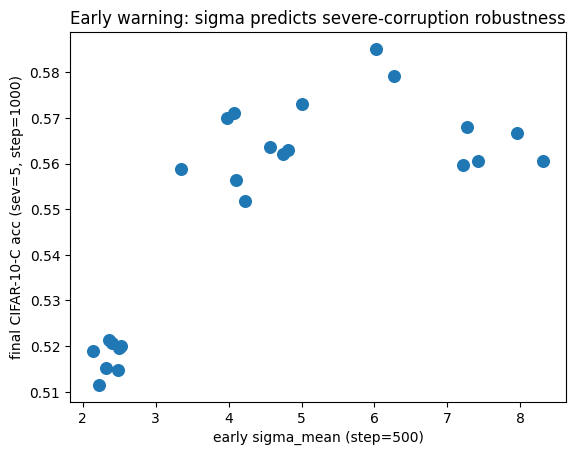

corr(early_sigma, final_c10c) = 0.753426672413274
corr(early_test_acc, final_c10c) = 0.8547072109448717


In [77]:
import matplotlib.pyplot as plt
import numpy as np

early_sigma = np.array([r["early_sigma"] for r in results])
early_acc   = np.array([r["early_test_acc"] for r in results])
final_c10c  = np.array([r["final_c10c_acc"] for r in results])

plt.figure()
plt.scatter(early_sigma, final_c10c, s=70)
plt.xlabel("early sigma_mean (step=500)")
plt.ylabel("final CIFAR-10-C acc (sev=5, step=1000)")
plt.title("Early warning: sigma predicts severe-corruption robustness")
plt.show()

corr_sigma = np.corrcoef(early_sigma, final_c10c)[0,1]
corr_acc   = np.corrcoef(early_acc, final_c10c)[0,1]
print("corr(early_sigma, final_c10c) =", corr_sigma)
print("corr(early_test_acc, final_c10c) =", corr_acc)

In [78]:
X = np.stack([np.ones_like(early_sigma), early_sigma, early_acc], axis=1)
beta, *_ = np.linalg.lstsq(X, final_c10c, rcond=None)
pred = X @ beta
r2 = 1 - np.sum((final_c10c - pred)**2) / np.sum((final_c10c - final_c10c.mean())**2)
print("Linear model: c10c ~ 1 + sigma + clean_acc")
print("beta =", beta)
print("R^2 =", r2)

Linear model: c10c ~ 1 + sigma + clean_acc
beta = [ 0.1790086  -0.00815005  0.66160101]
R^2 = 0.7727931701969484


In [79]:
def train_step_safe(model, opt, x, y):
    model.train()
    x, y = x.to(device), y.to(device)

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()

    acc = (logits.argmax(-1) == y).float().mean().item()
    return float(loss.item()), float(acc)

# Code: compute σ⋆ and bands from (a,b,c)

In [80]:
import numpy as np

def sensitivity_optimal_band(a, b, c, eta=0.01):
    """
    For concave quadratic R(s) = a s^2 + b s + c with a<0,
    return (s_star, R_star, (s_lo, s_hi)) where band satisfies
    R(s) >= (1-eta) R_star.
    """
    assert a < 0, "Need a<0 (concave) for an 'optimal band'."

    s_star = -b / (2*a)
    R_star = a*s_star**2 + b*s_star + c
    thr = (1-eta) * R_star

    # Solve a s^2 + b s + c = thr  -> a s^2 + b s + (c-thr)=0
    A, B, C = a, b, (c - thr)
    disc = B*B - 4*A*C
    if disc < 0:
        # Numerical issue; treat as empty
        return s_star, R_star, (np.nan, np.nan)

    r1 = (-B - np.sqrt(disc)) / (2*A)
    r2 = (-B + np.sqrt(disc)) / (2*A)
    s_lo, s_hi = (min(r1, r2), max(r1, r2))
    return float(s_star), float(R_star), (float(s_lo), float(s_hi))

a, b, c = -0.000088, 0.004488, 0.494380

for eta in [0.01, 0.02]:
    s_star, R_star, (s_lo, s_hi) = sensitivity_optimal_band(a, b, c, eta=eta)
    print(f"eta={eta:.2%}: sigma*={s_star:.3f}, R*={R_star:.6f}, band=[{s_lo:.3f}, {s_hi:.3f}]")

eta=1.00%: sigma*=25.500, R*=0.551602, band=[17.583, 33.417]
eta=2.00%: sigma*=25.500, R*=0.551602, band=[14.303, 36.697]


# Code: overlay the optimal band on scatter (severity 5)

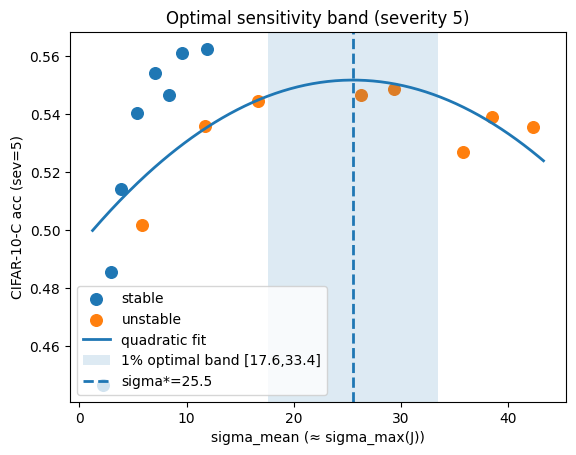

In [81]:
import matplotlib.pyplot as plt
import numpy as np

a, b, c = -0.000088, 0.004488, 0.494380

# compute band
s_star, R_star, (s_lo, s_hi) = sensitivity_optimal_band(a, b, c, eta=0.01)

# data (edit if your variable names differ)
stable_sigma = np.array(cifar_demo3_stable["sigma_mean"], dtype=float)
stable_c10c  = np.array(cifar_demo3_stable["c10c_acc_mean"], dtype=float)

unst_sigma = np.array(cifar_demo3_unst["sigma_mean"], dtype=float)
unst_c10c  = np.array(cifar_demo3_unst["c10c_acc_mean"], dtype=float)

# curve
s_grid = np.linspace(
    min(stable_sigma.min(), unst_sigma.min()) - 1.0,
    max(stable_sigma.max(), unst_sigma.max()) + 1.0,
    300
)
R_grid = a*s_grid**2 + b*s_grid + c

plt.figure()
plt.scatter(stable_sigma, stable_c10c, s=70, label="stable")
plt.scatter(unst_sigma,   unst_c10c,   s=70, label="unstable")

plt.plot(s_grid, R_grid, linewidth=2, label="quadratic fit")

# optimal band shading
plt.axvspan(s_lo, s_hi, alpha=0.15, label=f"1% optimal band [{s_lo:.1f},{s_hi:.1f}]")
plt.axvline(s_star, linestyle="--", linewidth=2, label=f"sigma*={s_star:.1f}")

plt.xlabel("sigma_mean (≈ sigma_max(J))")
plt.ylabel("CIFAR-10-C acc (sev=5)")
plt.title("Optimal sensitivity band (severity 5)")
plt.legend()
plt.show()

# One more “formal” experiment you can code: band stability across severities

In [82]:
def fit_quadratic_and_band(sigmas, accs, eta=0.01):
    sigmas = np.asarray(sigmas, float)
    accs   = np.asarray(accs, float)
    coeffs = np.polyfit(sigmas, accs, deg=2)  # returns [a,b,c]
    a, b, c = coeffs
    if a >= 0:
        return (a,b,c), (np.nan, np.nan, (np.nan, np.nan))
    s_star, R_star, band = sensitivity_optimal_band(a,b,c,eta=eta)
    return (float(a), float(b), float(c)), (s_star, R_star, band)

# Example usage: build per-severity datasets and fit
# You'd fill sigmas_s and accs_s from your logs for each severity.

## Experiment: “band occupancy” over training

In [83]:
import numpy as np

B1 = (17.583, 33.417)   # 1% band
B2 = (14.303, 36.697)   # 2% band

def band_stats(logs, band):
    sig = np.array(logs["sigma_mean"], dtype=float)
    rob = np.array(logs["c10c_acc_mean"], dtype=float)

    inside = (sig >= band[0]) & (sig <= band[1])
    frac_inside = inside.mean()

    if inside.any():
        rob_in = rob[inside].mean()
    else:
        rob_in = np.nan

    if (~inside).any():
        rob_out = rob[~inside].mean()
    else:
        rob_out = np.nan

    return {
        "frac_inside": float(frac_inside),
        "rob_in": float(rob_in),
        "rob_out": float(rob_out),
        "n": int(len(sig))
    }

print("Stable band stats (1%):", band_stats(cifar_demo3_stable, B1))
print("Unstable band stats (1%):", band_stats(cifar_demo3_unst, B1))

Stable band stats (1%): {'frac_inside': 0.0, 'rob_in': nan, 'rob_out': 0.5262966666666666, 'n': 8}
Unstable band stats (1%): {'frac_inside': 0.25, 'rob_in': 0.5476133333333333, 'rob_out': 0.5304655555555556, 'n': 8}


In [85]:
#plt.style.use('seaborn-v0_8-poster')
#plt.style.use('bmh')
plt.style.use('default')

In [84]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def use_scientific_lux():

    mpl.rcParams.update({

        # Figure
        "figure.facecolor": "#0f172a",      # deep charcoal-blue
        "axes.facecolor": "#0f172a",
        "savefig.facecolor": "#0f172a",

        # Text
        "text.color": "#e2e8f0",
        "axes.labelcolor": "#e2e8f0",
        "axes.titlecolor": "#f8fafc",
        "xtick.color": "#cbd5e1",
        "ytick.color": "#cbd5e1",

        # Grid
        "axes.grid": True,
        "grid.color": "#334155",
        "grid.alpha": 0.35,
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,

        # Lines
        "lines.linewidth": 2.5,
        "lines.markersize": 6,

        # Axes
        "axes.edgecolor": "#475569",
        "axes.linewidth": 1.2,

        # Font
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,

        # Legend
        "legend.frameon": False,

        # Custom scientific color cycle
        "axes.prop_cycle": mpl.cycler(color=[
            "#1b998b",  # teal
            "#e84855",  # coral
            "#f9a826",  # amber
            "#9a8cfc",  # lavender
            "#3fa7d6",  # sky blue
            "#90be6d"   # muted green
        ])
    })

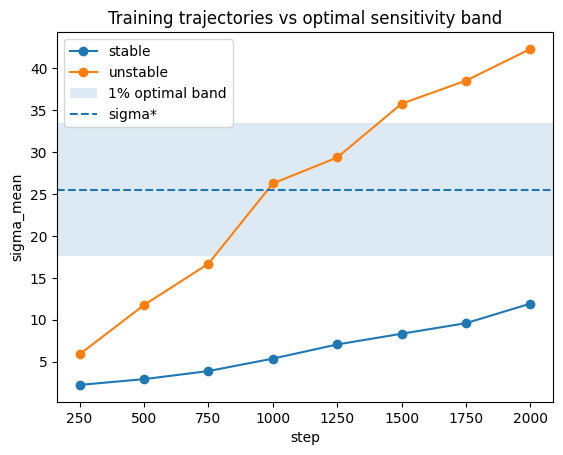

In [86]:
import matplotlib.pyplot as plt
import numpy as np

B1 = (17.583, 33.417)

stable_sigma = np.array(cifar_demo3_stable["sigma_mean"], float)
unst_sigma   = np.array(cifar_demo3_unst["sigma_mean"], float)

steps = np.array(cifar_demo3_stable["step"])

plt.figure()
plt.plot(steps, stable_sigma, marker="o", label="stable")
plt.plot(steps, unst_sigma, marker="o", label="unstable")

plt.axhspan(B1[0], B1[1], alpha=0.15, label="1% optimal band")
plt.axhline(25.5, linestyle="--", label="sigma*")

plt.xlabel("step")
plt.ylabel("sigma_mean")
#plt.xscale('log')
plt.legend()
plt.title("Training trajectories vs optimal sensitivity band")
plt.show()

# A Best upgrade: 2-panel “Mechanism → Effect” figure

In [87]:
import numpy as np
import matplotlib.pyplot as plt

def plot_band_and_robustness_advanced(
    steps,
    stable_sigma, unstable_sigma,
    stable_c10c_mean=None, stable_c10c_std=None,
    unstable_c10c_mean=None, unstable_c10c_std=None,
    band=(17.583, 33.417),
    sigma_star=25.5,
    title="Demo-3: Sensitivity band and severe-corruption robustness",
):
    steps = np.asarray(steps)

    stable_sigma = np.asarray(stable_sigma, float)
    unstable_sigma = np.asarray(unstable_sigma, float)

    has_rob = (stable_c10c_mean is not None) and (unstable_c10c_mean is not None)

    if has_rob:
        stable_c10c_mean = np.asarray(stable_c10c_mean, float)
        unstable_c10c_mean = np.asarray(unstable_c10c_mean, float)
        stable_c10c_std = np.zeros_like(stable_c10c_mean) if stable_c10c_std is None else np.asarray(stable_c10c_std, float)
        unstable_c10c_std = np.zeros_like(unstable_c10c_mean) if unstable_c10c_std is None else np.asarray(unstable_c10c_std, float)

    fig = plt.figure(figsize=(8.2, 6.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[2.0, 1.4], hspace=0.20)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax1) if has_rob else None

    # --- Panel 1: sensitivity trajectories ---
    lo, hi = band
    ax1.axhspan(lo, hi, alpha=0.18, label=f"1% optimal band [{lo:.1f},{hi:.1f}]")
    ax1.axhline(sigma_star, linestyle="--", linewidth=1.6, label=r"$\sigma^*$")

    l_st = ax1.plot(steps, stable_sigma, marker="o", linewidth=2.0, label="stable")
    l_un = ax1.plot(steps, unstable_sigma, marker="o", linewidth=2.0, label="unstable")

    ax1.set_ylabel(r"sensitivity  $S(\theta)$  (sigma_mean)")
    ax1.set_title(title)

    # entry/exit markers for unstable
    inside = (unstable_sigma >= lo) & (unstable_sigma <= hi)
    if inside.any():
        idxs = np.where(inside)[0]
        enter_i, exit_i = idxs[0], idxs[-1]
        ax1.scatter([steps[enter_i]], [unstable_sigma[enter_i]], s=80, zorder=5)
        ax1.annotate(
            "enters band",
            xy=(steps[enter_i], unstable_sigma[enter_i]),
            xytext=(10, 18), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1.2),
        )
        ax1.scatter([steps[exit_i]], [unstable_sigma[exit_i]], s=80, zorder=5)
        ax1.annotate(
            "last in band",
            xy=(steps[exit_i], unstable_sigma[exit_i]),
            xytext=(10, -22), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", lw=1.2),
        )

    # regime labels (under / in / over)
    ax1.text(0.02, 0.05, "under-sensitive", transform=ax1.transAxes, fontsize=10, alpha=0.9)
    ax1.text(0.54, 0.64, "near-optimal band", transform=ax1.transAxes, fontsize=10, alpha=0.9)
    ax1.text(0.80, 0.93, "overshoot", transform=ax1.transAxes, fontsize=10, alpha=0.9, va="top")

    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", frameon=True)

    # --- Panel 2: robustness (optional, but strongly recommended) ---
    if has_rob:
        ax2.plot(steps, stable_c10c_mean, marker="o", linewidth=2.0, label="stable sev=5")
        ax2.fill_between(steps, stable_c10c_mean - stable_c10c_std, stable_c10c_mean + stable_c10c_std, alpha=0.18)

        ax2.plot(steps, unstable_c10c_mean, marker="o", linewidth=2.0, label="unstable sev=5")
        ax2.fill_between(steps, unstable_c10c_mean - unstable_c10c_std, unstable_c10c_mean + unstable_c10c_std, alpha=0.18)

        ax2.set_ylabel("CIFAR-10-C acc (sev=5)")
        ax2.set_xlabel("training step")
        ax2.grid(True, alpha=0.25)
        ax2.legend(loc="lower right", frameon=True)

        # Optional: highlight overshoot region in bottom panel
        if inside.any():
            ax2.axvspan(steps[enter_i], steps[exit_i], alpha=0.08, label="in-band period")

    else:
        ax1.set_xlabel("training step")

    plt.show()

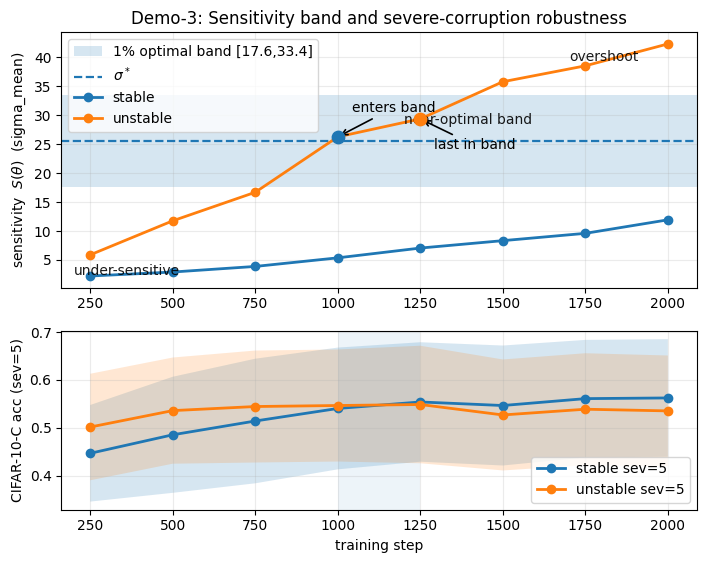

In [88]:
steps = cifar_demo3_stable["step"]

plot_band_and_robustness_advanced(
    steps=steps,
    stable_sigma=cifar_demo3_stable["sigma_mean"],
    unstable_sigma=cifar_demo3_unst["sigma_mean"],
    stable_c10c_mean=cifar_demo3_stable["c10c_acc_mean"],
    stable_c10c_std=cifar_demo3_stable["c10c_acc_std"],
    unstable_c10c_mean=cifar_demo3_unst["c10c_acc_mean"],
    unstable_c10c_std=cifar_demo3_unst["c10c_acc_std"],
    band=(17.583, 33.417),
    sigma_star=25.5,
)